# Part I — Data Loading and Environment Setup
- Initialize analysis environment and load processed dataset.
- Automated path resolution ensures reproducibility across machines.
- Configure display options for effective data inspection.

In [1]:
# Step 1: Setup and Automatic Dataset Loading



from pathlib import Path



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns



# Plotting & Pandas display settings

plt.style.use("seaborn-v0_8")

sns.set(font_scale=1.1)



pd.set_option("display.max_columns", 100)

pd.set_option("display.width", 140)



# Find project root by walking up until a folder containing `data/` is found

def find_project_root(marker: str = "data") -> Path:

    cwd = Path.cwd()

    for path in (cwd, *cwd.parents):

        if (path / marker).exists():

            return path

    raise FileNotFoundError(f"Could not find project root containing '{marker}' directory from {cwd}")



PROJECT_ROOT = find_project_root()



# Construct path to processed dataset inside repo

DATA_PATH = PROJECT_ROOT / "notebooks" / "model_ready_dataset.csv"



# Load dataset

df = pd.read_csv(DATA_PATH)



print(f"Loaded dataset from: {DATA_PATH}")

print("Shape:", df.shape)



df.head()


Loaded dataset from: C:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\notebooks\model_ready_dataset.csv
Shape: (327, 18)


,date,cpi_yoy,petrol_yoy,bank_rate,fx_usd,gva_growth,unemp_rate,cpi_yoy_l1,cpi_yoy_l3,cpi_yoy_l6,petrol_yoy_l1,fx_usd_l1,bank_rate_l1,gva_growth_l1,unemp_rate_l1,cpi_t1,cpi_t3,cpi_t5
0,1997-12-01,1.7,3.4,5.9375,1.6597,1.4,6.4,1.9,1.8,1.7,7.5,1.6890,5.9375,1.0,6.5,1.5,1.7,2.0
1,1998-01-01,1.5,3.2,7.2500,1.6353,1.4,6.4,1.7,1.9,2.0,3.4,1.6597,5.9375,1.4,6.4,1.6,1.8,1.7
2,1998-02-01,1.6,2.9,7.2500,1.6407,1.4,6.4,1.5,1.9,2.0,3.2,1.6353,7.2500,1.4,6.4,1.7,2.0,1.4
3,1998-03-01,1.7,3.3,7.2500,1.6620,0.8,6.3,1.6,1.7,1.8,2.9,1.6407,7.2500,1.4,6.4,1.8,1.7,1.3
4,1998-04-01,1.8,10.0,7.2500,1.6733,0.9,6.3,1.7,1.5,1.9,3.3,1.6620,7.2500,0.8,6.3,2.0,1.4,1.4


## 1. Environment Setup and Data Loading

This section prepares the computational environment and loads the model-ready dataset
used for hybrid inflation forecasting. Reproducibility is ensured by fixing random seeds.
The dataset is assumed to contain monthly macroeconomic features, a date column, and
multi-horizon inflation targets (t+1, t+3, t+5).


In [2]:
import os
os.environ["KERAS_BACKEND"] = "torch"
import json
import random
import itertools

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import keras
from keras import layers, models, callbacks, optimizers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

print("Environment initialised with fixed seed:", SEED)


Environment initialised with fixed seed: 42


## 2. Feature Definition and Time-Based Data Partitioning

This section defines the explanatory variables and target variables and applies a fixed
calendar-based data split to preserve the temporal structure of the series.

The dataset is divided as follows:
- Training set: observations up to 31 December 2017
- Validation set: observations from 1 January 2018 to 31 December 2021
- Test set: observations from 1 January 2022 onwards


In [3]:
target_cols = ["cpi_t1", "cpi_t3", "cpi_t5"]
exclude_cols = ["date"] + target_cols
feature_cols = [c for c in df.columns if c not in exclude_cols]

print("Targets:", target_cols)
print("Number of features:", len(feature_cols))


Targets: ['cpi_t1', 'cpi_t3', 'cpi_t5']
Number of features: 14


In [4]:
train_end = "2017-12-31"
val_end   = "2021-12-31"

train_df = df[df["date"] <= train_end].copy()
val_df   = df[(df["date"] > train_end) & (df["date"] <= val_end)].copy()
test_df  = df[df["date"] > val_end].copy()

print("Train:", train_df.shape, train_df["date"].min(), "→", train_df["date"].max())
print("Val  :", val_df.shape,   val_df["date"].min(),   "→", val_df["date"].max())
print("Test :", test_df.shape,  test_df["date"].min(),  "→", test_df["date"].max())


Train: (241, 18) 1997-12-01 → 2017-12-01
Val  : (48, 18) 2018-01-01 → 2021-12-01
Test : (38, 18) 2022-01-01 → 2025-02-01


In [5]:
X_train = train_df[feature_cols].copy()
X_val   = val_df[feature_cols].copy()
X_test  = test_df[feature_cols].copy()

y_train = train_df[target_cols].copy()
y_val   = val_df[target_cols].copy()
y_test  = test_df[target_cols].copy()

dates_train = train_df["date"].reset_index(drop=True)
dates_val   = val_df["date"].reset_index(drop=True)
dates_test  = test_df["date"].reset_index(drop=True)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

X_train: (241, 14) y_train: (241, 3)
X_val  : (48, 14) y_val  : (48, 3)
X_test : (38, 14) y_test : (38, 3)


## 3. LSTM Temporal Learner with Horizon-Specific Hyperparameter Tuning (Hybrid Stage 1)

This section implements the first stage of the hybrid inflation forecasting framework using a
Long Short-Term Memory (LSTM) network. The LSTM is designed to learn nonlinear temporal dependencies
in inflation dynamics through a direct multi-horizon strategy. Separate LSTM models are estimated
for one-, three-, and five-month-ahead targets (`cpi_t1`, `cpi_t3`, `cpi_t5`).

The procedure comprises the following sub-steps:

1. **Feature standardisation**: Explanatory variables are standardised using training-set statistics only,
   ensuring numerical stability during optimisation and preventing information leakage.

2. **Sequence construction**: A sliding-window approach generates input sequences of length `LOOKBACK`,
   where each sequence summarises the previous `LOOKBACK` months of macroeconomic information.

3. **Hyperparameter selection (validation-based)**: For each horizon, candidate configurations
   (lookback length, number of LSTM units, dropout, learning rate, and batch size) are evaluated on the
   validation set. Validation RMSE is used as the primary selection criterion, while MAE and R² are
   reported as complementary measures.

4. **Final horizon-specific estimation**: Using the selected hyperparameters, each LSTM model is
   re-estimated and used to generate out-of-sample predictions for the training, validation, and test
   subsets. These predictions represent learned temporal signals and will be used as stacking features
   in the second-stage XGBoost model.


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

print("Scaled shapes:")
print("Train:", X_train_scaled.shape)
print("Val  :", X_val_scaled.shape)
print("Test :", X_test_scaled.shape)


Scaled shapes:
Train: (241, 14)
Val  : (48, 14)
Test : (38, 14)


In [7]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def make_sequences(X_scaled, y_series, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X_scaled)):
        X_seq.append(X_scaled[i - lookback:i, :])
        y_seq.append(y_series.iloc[i])
    return np.array(X_seq), np.array(y_seq)

def metrics_block(y_true, y_pred):
    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred)
    }


In [8]:
import itertools
import random
from keras import layers, models, optimizers, callbacks

random.seed(42)

def build_lstm_model(lookback, n_features, units, dropout, lr):
    model = models.Sequential([
        layers.Input(shape=(lookback, n_features)),
        layers.LSTM(units, dropout=dropout),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=lr), loss="mse")
    return model

# Search space (you can adjust max_trials later)
search_space = {
    "lookback": [6,12],
    "units": [32, 64, 128],
    "dropout": [0.0, 0.2, 0.3],
    "lr": [1e-3, 5e-4],
    "batch_size": [16, 32],
    "epochs": [150]
}

def tune_lstm_for_horizon(horizon, max_trials=12):
    # Build full grid
    full_grid = list(itertools.product(
        search_space["lookback"],
        search_space["units"],
        search_space["dropout"],
        search_space["lr"],
        search_space["batch_size"],
        search_space["epochs"]
    ))

    # Random sample so lookbacks appear even with limited trials
    grid = random.sample(full_grid, k=min(max_trials, len(full_grid)))

    best = None

    for i, (lb, u, dr, lr, bs, ep) in enumerate(grid, start=1):
        Xtr, ytr = make_sequences(X_train_scaled, y_train[horizon], lb)
        Xva, yva = make_sequences(X_val_scaled,   y_val[horizon],   lb)

        model = build_lstm_model(lb, Xtr.shape[-1], u, dr, lr)

        es = callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)

        model.fit(
            Xtr, ytr,
            validation_data=(Xva, yva),
            epochs=ep,
            batch_size=bs,
            verbose=0,
            callbacks=[es]
        )

        yva_pred = model.predict(Xva, verbose=0).ravel()
        val_m = metrics_block(yva, yva_pred)

        # store current trial result
        trial_row = {
            "trial": i,
            "lookback": lb,
            "units": u,
            "dropout": dr,
            "lr": lr,
            "batch_size": bs,
            "epochs": ep,
            **val_m
        }

        # update best by RMSE
        if best is None or trial_row["rmse"] < best["rmse"]:
            best = trial_row

        print(f"[{horizon}] Trial {i}: RMSE={trial_row['rmse']:.4f} | "
              f"lb={lb}, units={u}, dropout={dr}, lr={lr}, bs={bs}")

    return best

# Run tuning for t1/t3/t5 and print best summary
horizons = ["cpi_t1", "cpi_t3", "cpi_t5"]
best_params = {}

for h in horizons:
    print("\n" + "="*60)
    print("TUNING:", h)
    print("="*60)
    best_params[h] = tune_lstm_for_horizon(h, max_trials=12)

print("\n" + "="*60)
print("BEST CONFIGURATIONS (by validation RMSE)")
print("="*60)

for h in horizons:
    bp = best_params[h]
    print(f"\nHorizon: {h}")
    print(f"  Best Trial   : {bp['trial']}")
    print(f"  Lookback     : {bp['lookback']}")
    print(f"  Units        : {bp['units']}")
    print(f"  Dropout      : {bp['dropout']}")
    print(f"  Learning rate: {bp['lr']}")
    print(f"  Batch size   : {bp['batch_size']}")
    print(f"  Epochs       : {bp['epochs']}")
    print(f"  Val MAE      : {bp['mae']:.4f}")
    print(f"  Val RMSE     : {bp['rmse']:.4f}")
    print(f"  Val R2       : {bp['r2']:.4f}")



TUNING: cpi_t1


[cpi_t1] Trial 1: RMSE=1.3035 | lb=6, units=64, dropout=0.0, lr=0.0005, bs=16


[cpi_t1] Trial 2: RMSE=1.6459 | lb=6, units=32, dropout=0.0, lr=0.0005, bs=32


[cpi_t1] Trial 3: RMSE=1.2162 | lb=6, units=128, dropout=0.3, lr=0.0005, bs=32


[cpi_t1] Trial 4: RMSE=1.0941 | lb=6, units=128, dropout=0.2, lr=0.0005, bs=32


...

[cpi_t5] Trial 8: RMSE=2.5671 | lb=12, units=128, dropout=0.0, lr=0.0005, bs=32


[cpi_t5] Trial 9: RMSE=2.4402 | lb=6, units=32, dropout=0.3, lr=0.0005, bs=32


[cpi_t5] Trial 10: RMSE=2.6261 | lb=12, units=64, dropout=0.0, lr=0.001, bs=16


[cpi_t5] Trial 11: RMSE=2.3958 | lb=6, units=32, dropout=0.0, lr=0.0005, bs=32


[cpi_t5] Trial 12: RMSE=2.4169 | lb=12, units=64, dropout=0.2, lr=0.0005, bs=32

BEST CONFIGURATIONS (by validation RMSE)

Horizon: cpi_t1
  Best Trial   : 5
  Lookback     : 6
  Units        : 128
  Dropout      : 0.2
  Learning rate: 0.001
  Batch size   : 16
  Epochs       : 150
  Val MAE      : 0.7318
  Val RMSE     : 1.0313
  Val R2       : 0.3450

Horizon: cpi_t3
  Best Trial   : 8
  Lookback     : 6
  Units        : 128
  Dropout      : 0.3
  Learning rate: 0.0005
  Batch size   : 32
  Epochs       : 150
  Val MAE      : 0.8869
  Val RMSE     : 1.2683
  Val R2       : 0.3868

Horizon: cpi_t5
  Best Trial   : 1
  Lookback     : 6
  Units        : 128
  Dropout      : 0.3
  Learning rate: 0.001
  Batch size   : 32
  Epochs       : 150
  Val MAE      : 1.4086
  Val RMSE     : 1.9832
  Val R2       : 0.1840


In [9]:
lstm_preds_train = pd.DataFrame({"date": dates_train})
lstm_preds_val   = pd.DataFrame({"date": dates_val})
lstm_preds_test  = pd.DataFrame({"date": dates_test})

def pad_preds(n_rows, lookback, preds):
    out = np.full(n_rows, np.nan)
    out[lookback:] = preds
    return out

final_models = {}

for h in horizons:
    bp = best_params[h]
    lb = bp["lookback"]

    Xtr, ytr = make_sequences(X_train_scaled, y_train[h], lb)
    Xva, yva = make_sequences(X_val_scaled,   y_val[h],   lb)
    Xte, yte = make_sequences(X_test_scaled,  y_test[h],  lb)

    model = build_lstm_model(lb, Xtr.shape[-1], bp["units"], bp["dropout"], bp["lr"])

    es = callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

    print("\n" + "-"*60)
    print("FINAL TRAINING:", h, "| Using best params:", {k: bp[k] for k in ["lookback","units","dropout","lr","batch_size","epochs"]})
    print("-"*60)

    model.fit(
        Xtr, ytr,
        validation_data=(Xva, yva),
        epochs=bp["epochs"],
        batch_size=bp["batch_size"],
        verbose=1,
        callbacks=[es]
    )

    # predictions
    ytr_pred = model.predict(Xtr, verbose=0).ravel()
    yva_pred = model.predict(Xva, verbose=0).ravel()
    yte_pred = model.predict(Xte, verbose=0).ravel()

    # store aligned (with NaN padding)
    lstm_preds_train[f"lstm_pred_{h[-2:]}"] = pad_preds(len(dates_train), lb, ytr_pred)
    lstm_preds_val[f"lstm_pred_{h[-2:]}"]   = pad_preds(len(dates_val),   lb, yva_pred)
    lstm_preds_test[f"lstm_pred_{h[-2:]}"]  = pad_preds(len(dates_test),  lb, yte_pred)

    final_models[h] = model

print("\nPreview of LSTM stacking features (test):")
display(lstm_preds_test.head(20))



------------------------------------------------------------
FINAL TRAINING: cpi_t1 | Using best params: {'lookback': 6, 'units': 128, 'dropout': 0.2, 'lr': 0.001, 'batch_size': 16, 'epochs': 150}
------------------------------------------------------------


Epoch 1/150


 1/15 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - loss: 4.1090

 2/15 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 5.0276

 4/15 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 4.9448

...

6/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.2758

7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.2721

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.2470 - val_loss: 5.2568



Preview of LSTM stacking features (test):


,date,lstm_pred_t1,lstm_pred_t3,lstm_pred_t5
0,2022-01-01,NaN,NaN,NaN
1,2022-02-01,NaN,NaN,NaN
2,2022-03-01,NaN,NaN,NaN
3,2022-04-01,NaN,NaN,NaN
4,2022-05-01,NaN,NaN,NaN
5,2022-06-01,NaN,NaN,NaN
6,2022-07-01,5.047827,4.071525,4.068467
7,2022-08-01,5.217827,4.135388,4.161959
8,2022-09-01,5.326700,4.100024,4.167315
9,2022-10-01,5.364622,3.980494,4.090040


### 3.5 Visual Diagnostics of the LSTM Temporal Learner

To assess predictive calibration and temporal tracking, the tuned LSTM models are evaluated using
two complementary visual diagnostics for each horizon (t+1, t+3, t+5) and each data partition
(training, validation, and test):

1. **Scatter plots (Actual vs Predicted)**: These plots assess calibration and systematic bias by
   comparing predicted values against realised inflation. A 45-degree reference line is included
   to indicate perfect agreement.

2. **Time-series line plots (Actual vs Predicted)**: These plots evaluate how well the model tracks
   inflation dynamics over time, including turning points and regime changes.

For each plot, MAE, RMSE, and R² are reported to provide quantitative context alongside the visuals.
Due to the rolling-window requirement, the first `LOOKBACK` observations in each partition do not
admit valid sequence-based predictions and are excluded from evaluation.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def eval_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

def prepare_eval_df(preds_df, y_df):
    df = preds_df.copy()
    df["actual_t1"] = y_df["cpi_t1"].values
    df["actual_t3"] = y_df["cpi_t3"].values
    df["actual_t5"] = y_df["cpi_t5"].values
    # remove rows where LSTM preds are NaN (lookback padding)
    return df.dropna().reset_index(drop=True)

def plot_scatter_and_lines(preds_df, y_df, split_name):
    horizons = ["t1", "t3", "t5"]
    df = prepare_eval_df(preds_df, y_df)

    # ---------------------------
    # FIGURE 1: Scatter (A vs P)
    # ---------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, h in zip(axes, horizons):
        y_true = df[f"actual_{h}"]
        y_pred = df[f"lstm_pred_{h}"]
        m = eval_metrics(y_true, y_pred)

        ax.scatter(y_true, y_pred, alpha=0.7)
        lo = min(y_true.min(), y_pred.min())
        hi = max(y_true.max(), y_pred.max())
        ax.plot([lo, hi], [lo, hi], linestyle="--")

        ax.set_title(
            f"{split_name} | LSTM {h.upper()}\n"
            f"MAE={m['MAE']:.2f}, RMSE={m['RMSE']:.2f}, R²={m['R2']:.2f}"
        )
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")

    plt.suptitle(f"Actual vs Predicted (Scatter) — {split_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # -----------------------------------
    # FIGURE 2: Line (Actual vs Predicted)
    # -----------------------------------
    fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
    for ax, h in zip(axes, horizons):
        # Convert to datetime so we can use clean yearly ticks on x-axis
        dates  = pd.to_datetime(df["date"])
        y_true = df[f"actual_{h}"]
        y_pred = df[f"lstm_pred_{h}"]
        m = eval_metrics(y_true, y_pred)

        ax.plot(dates, y_true, label="Actual", linewidth=2)
        ax.plot(dates, y_pred, label="Predicted", linestyle="--")
        ax.set_title(
            f"{split_name} | LSTM {h.upper()} | "
            f"MAE={m['MAE']:.2f}, RMSE={m['RMSE']:.2f}, R²={m['R2']:.2f}"
        )
        ax.grid(True)
        ax.legend()

    # Format x-axis: show one tick per year to reduce clutter
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha="right")
    plt.suptitle(f"Actual vs Predicted Over Time — {split_name}", fontsize=14)
    plt.tight_layout()
    plt.show()


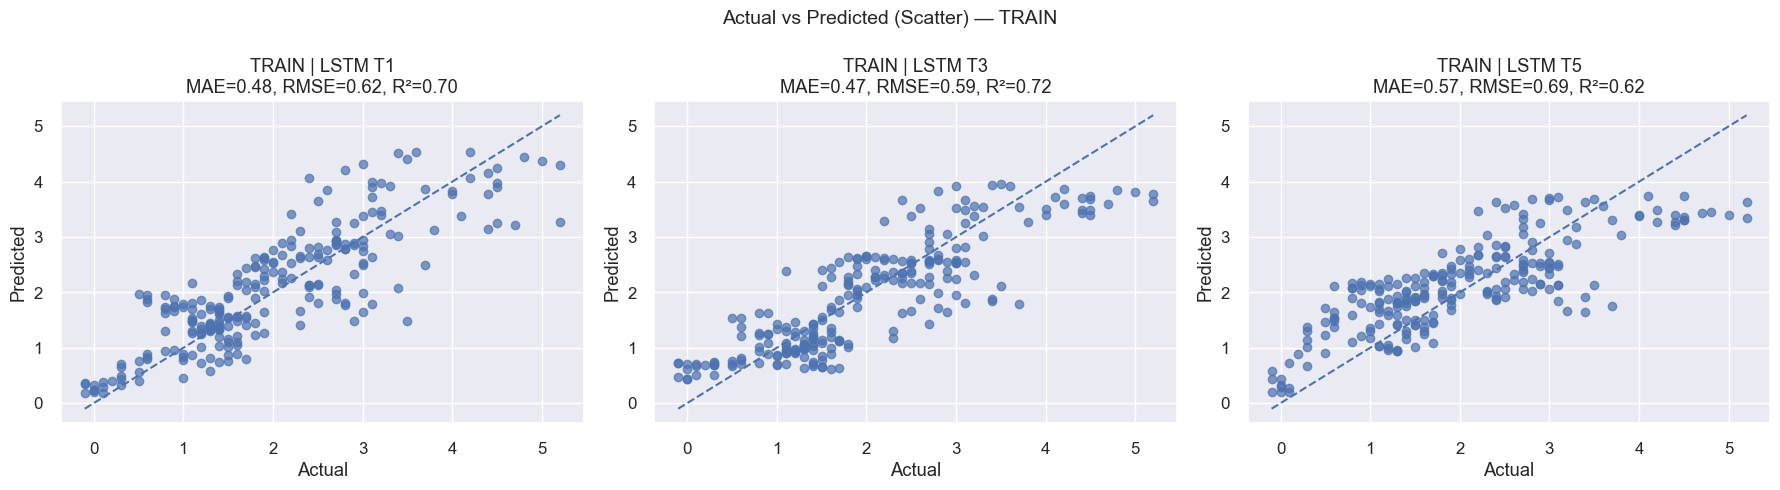

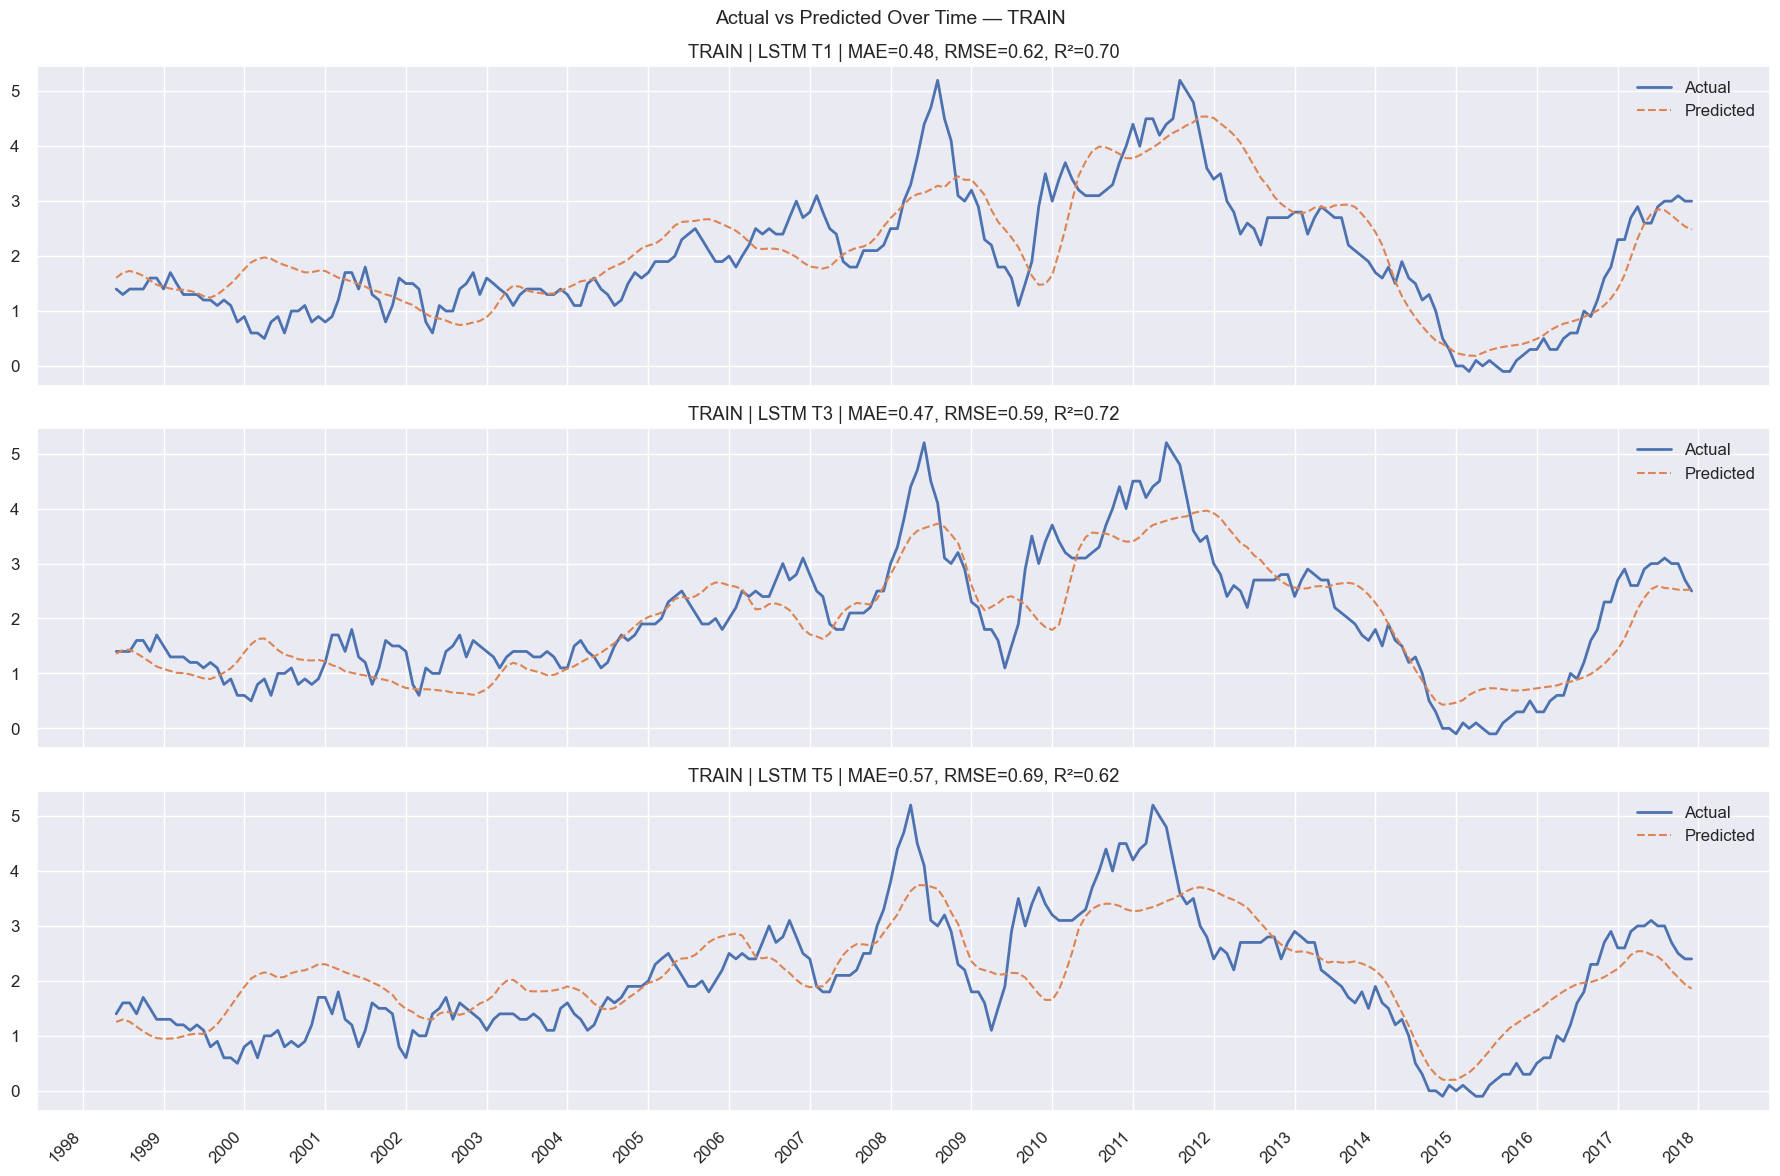

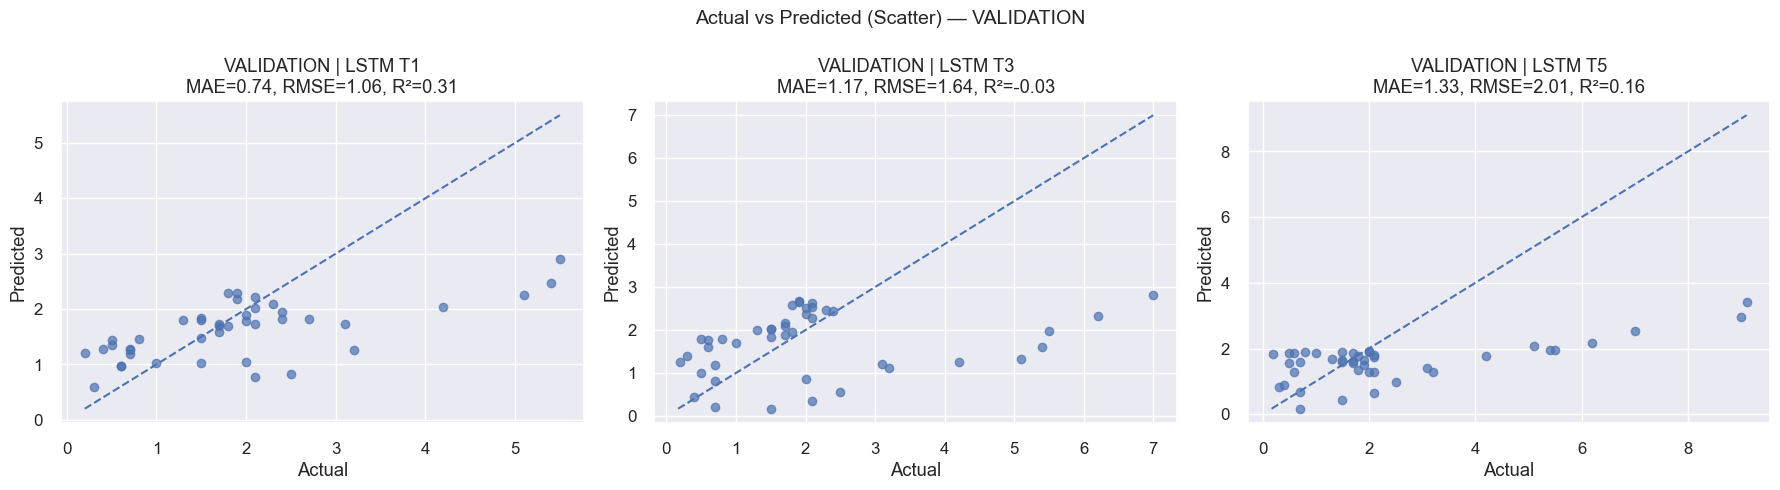

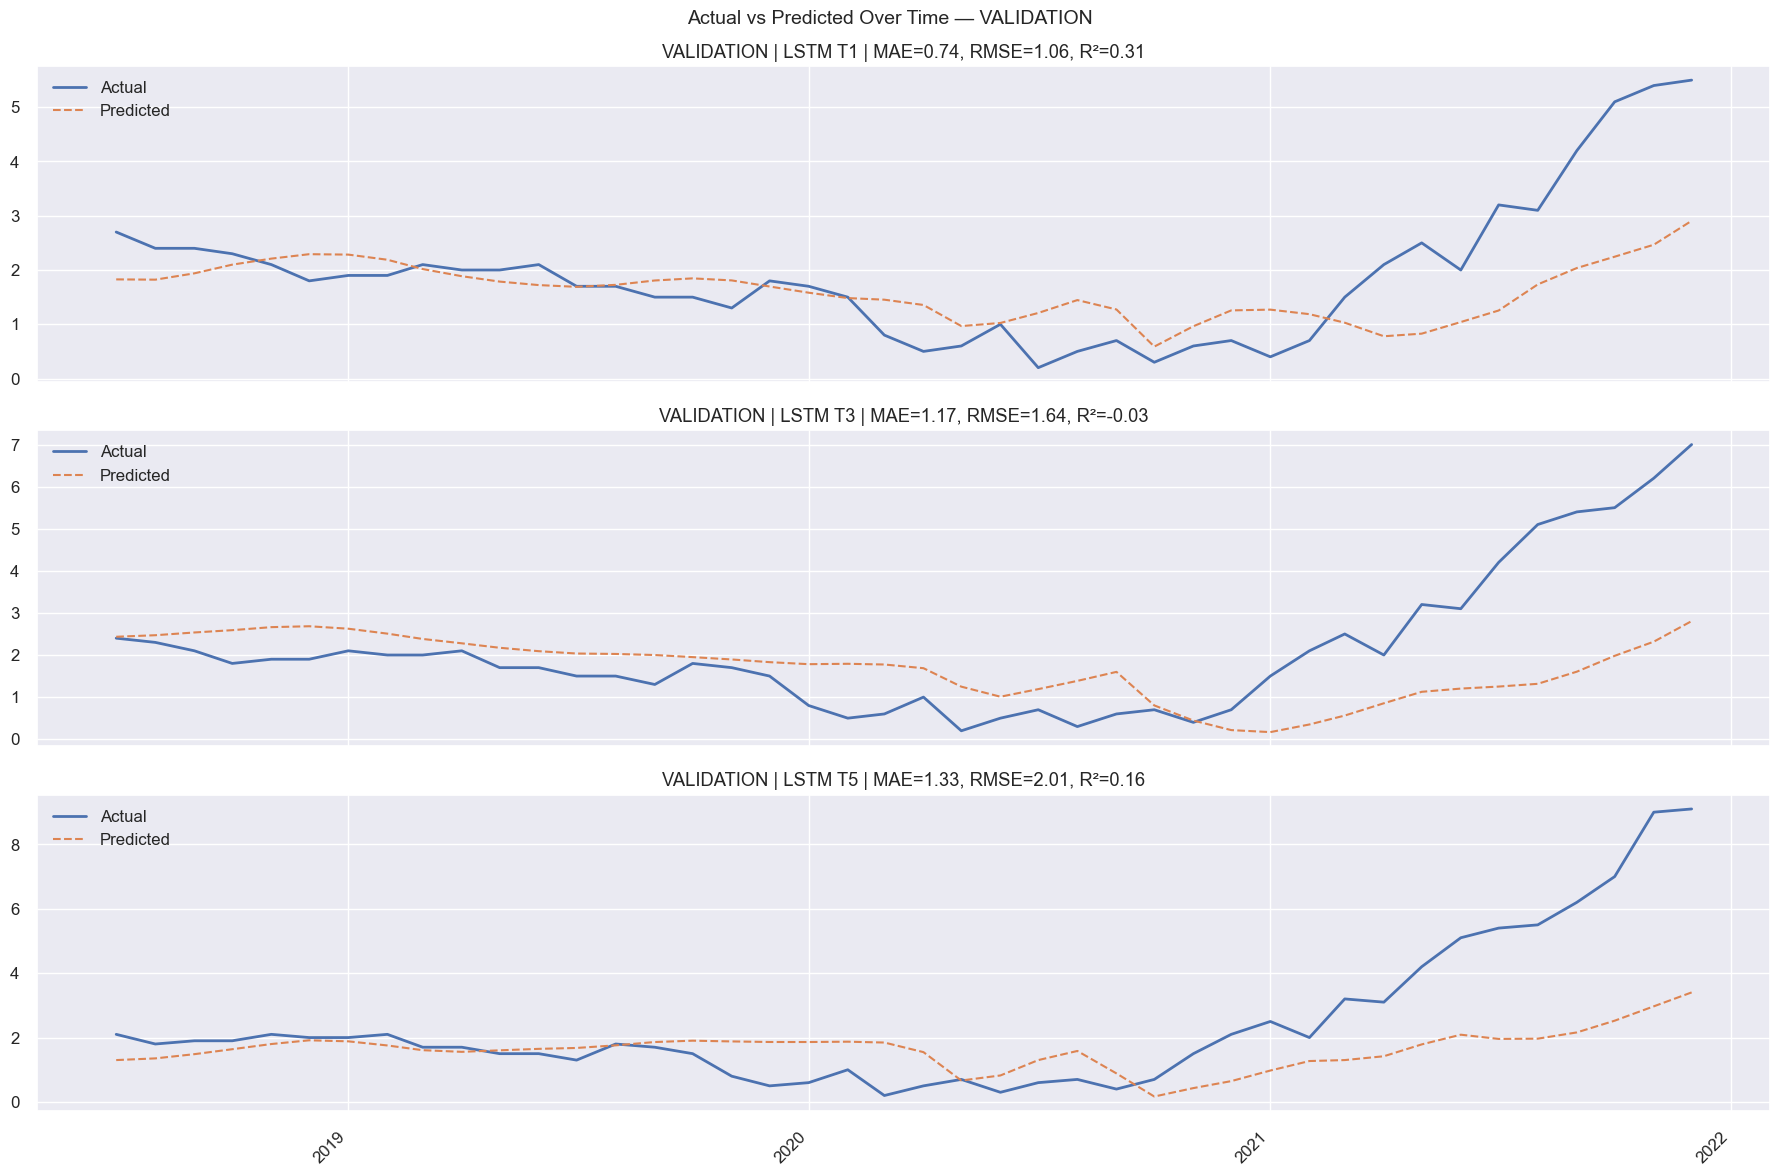

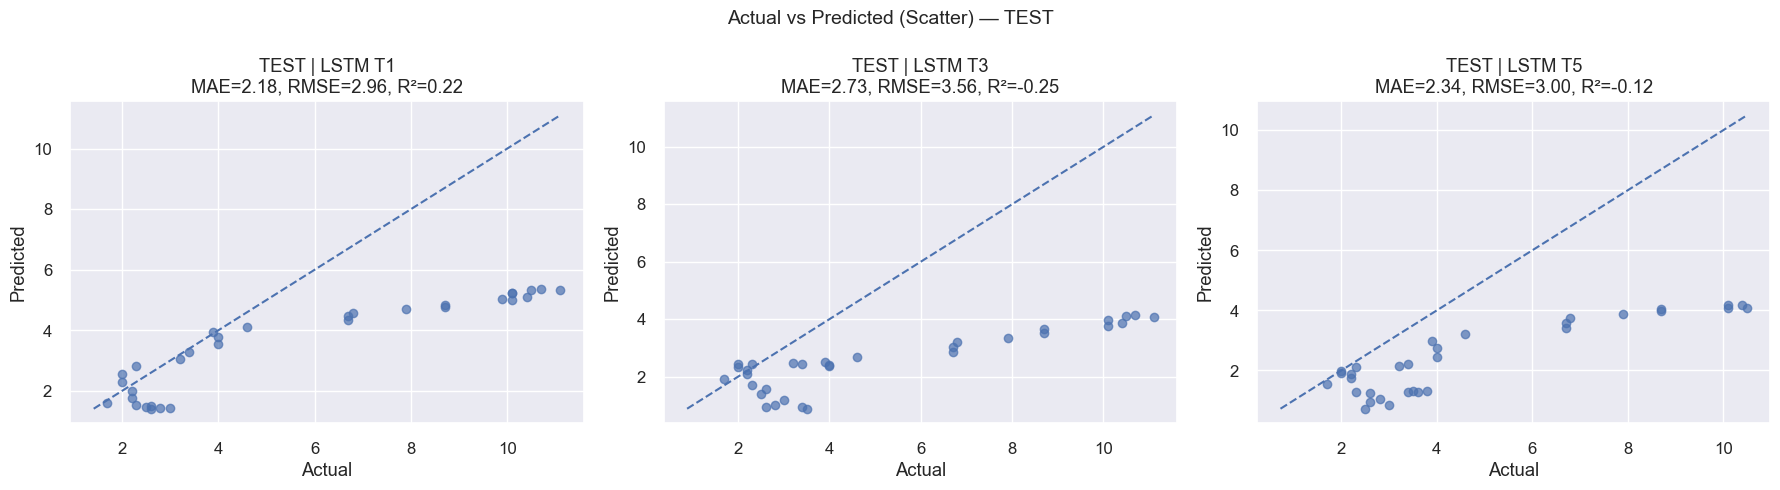

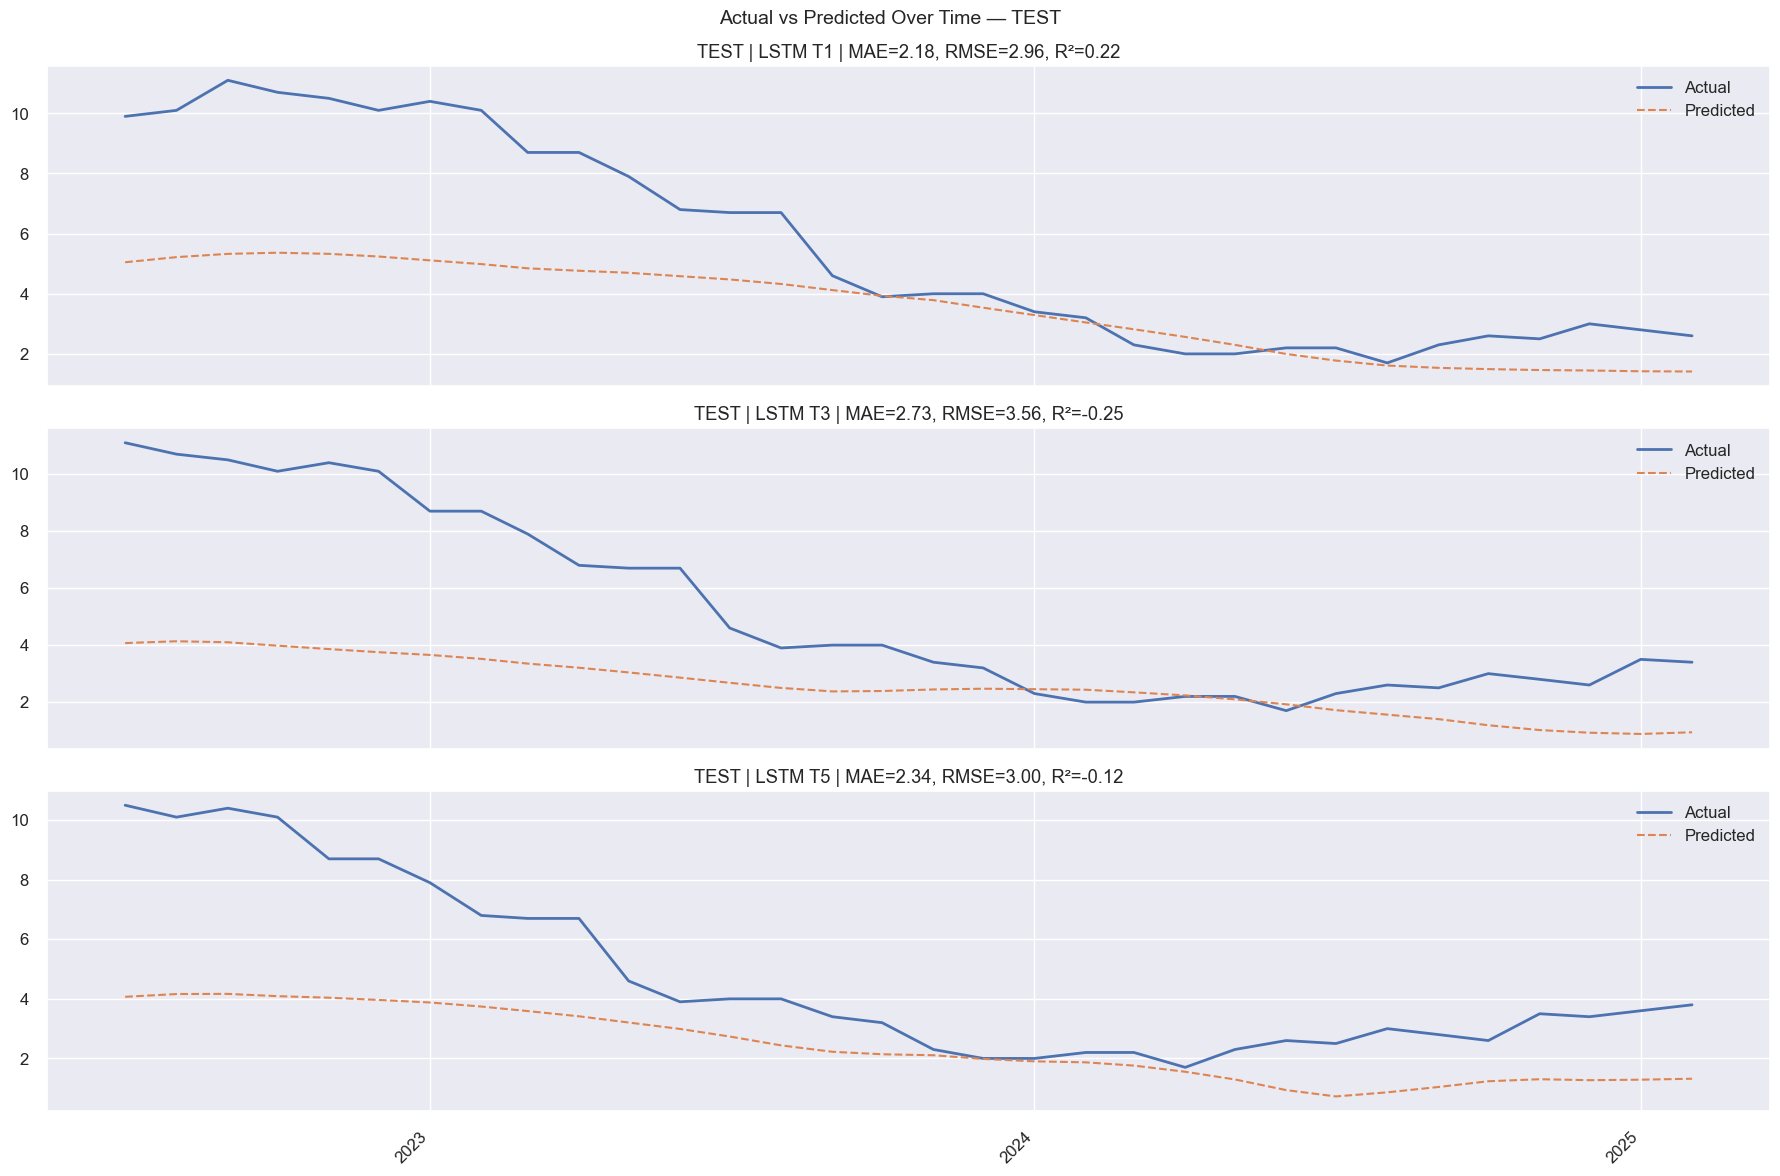

In [11]:
plot_scatter_and_lines(lstm_preds_train, y_train, "TRAIN")
plot_scatter_and_lines(lstm_preds_val,   y_val,   "VALIDATION")
plot_scatter_and_lines(lstm_preds_test,  y_test,  "TEST")


## 4. XGBoost Stacking Regressor with Horizon-Specific Hyperparameter Tuning (Hybrid Stage 2)

This section implements the second stage of the hybrid inflation forecasting framework using
Extreme Gradient Boosting (XGBoost). The objective of this stage is to combine the nonlinear
temporal signals learned by the LSTM models with contemporaneous macroeconomic information
in order to generate final hybrid forecasts.

In this stacking architecture, the LSTM predictions obtained in Stage 1 are treated as
additional explanatory variables. To ensure horizon consistency and avoid cross-horizon
contamination, separate XGBoost models are estimated for each forecast horizon. Specifically,
each XGBoost model uses all baseline macroeconomic features together with the corresponding
horizon-specific LSTM prediction.

The procedure comprises the following sub-steps:

1. **Stacked feature construction**: For each data partition (training, validation, and test),
   the relevant LSTM prediction (`lstm_pred_t1`, `lstm_pred_t3`, or `lstm_pred_t5`) is appended
   to the baseline feature matrix. Observations with missing LSTM predictions, arising from
   the LSTM lookback window, are removed to ensure a complete design matrix.

2. **Hyperparameter selection (validation-based)**: For each forecast horizon, a set of
   candidate XGBoost configurations (tree depth, learning rate, number of estimators,
   subsampling ratios, and regularisation terms) is evaluated on the validation set.
   Validation RMSE is employed as the primary selection criterion, while MAE and R² are
   reported as complementary measures.

3. **Final horizon-specific estimation**: Using the selected hyperparameters, each XGBoost
   model is re-estimated on the training data and used to generate predictions for the
   training, validation, and test subsets. These predictions constitute the final hybrid
   forecasts and are used for performance evaluation and interpretability analysis.


In [12]:
from xgboost import XGBRegressor
import numpy as np
import random

# Reuse global SEED defined earlier
random.seed(SEED)

def build_stacked_split(X_split, y_split, lstm_preds_split, horizon, lookback):
    """
    Construct stacked feature matrix for a given split and horizon by
    appending the horizon-specific LSTM prediction and dropping rows
    where this prediction is NaN (due to the LSTM lookback window).
    """
    h_short = horizon[-2:]  # 't1', 't3', or 't5'
    pred_col = f"lstm_pred_{h_short}"
    
    X_stacked = X_split.copy()
    X_stacked[pred_col] = lstm_preds_split[pred_col].values
    
    # Drop rows where the LSTM prediction is NaN
    mask = ~np.isnan(X_stacked[pred_col].to_numpy())
    X_stacked = X_stacked.loc[mask]
    y_h = y_split[horizon].loc[mask].to_numpy()
    
    return X_stacked, y_h


xgb_search_space = {
    "max_depth":       [3, 4, 5, 6],
    "learning_rate":   [0.03, 0.05, 0.1],
    "n_estimators":    [200, 400, 600],
    "subsample":       [0.7, 0.9, 1.0],
    "colsample_bytree":[0.7, 0.9, 1.0],
    "reg_lambda":      [0.0, 1.0, 3.0]
}

In [13]:
def tune_xgb_for_horizon(horizon, max_trials=25):
    """
    Hyperparameter search for the XGBoost stacking model for a given horizon,
    using validation RMSE as the selection criterion.
    """
    # Use the LSTM lookback for this horizon to define the usable sample
    lb = best_params[horizon]["lookback"]
    
    Xtr_s, ytr_s = build_stacked_split(X_train, y_train, lstm_preds_train, horizon, lb)
    Xva_s, yva_s = build_stacked_split(X_val,   y_val,   lstm_preds_val,   horizon, lb)
    
    # Build full grid then randomly subsample for efficiency
    full_grid = list(itertools.product(
        xgb_search_space["max_depth"],
        xgb_search_space["learning_rate"],
        xgb_search_space["n_estimators"],
        xgb_search_space["subsample"],
        xgb_search_space["colsample_bytree"],
        xgb_search_space["reg_lambda"]
    ))
    
    grid = random.sample(full_grid, k=min(max_trials, len(full_grid)))
    
    best = None
    
    for i, (md, lr, ne, ss, cs, rl) in enumerate(grid, start=1):
        model = XGBRegressor(
            max_depth=md,
            learning_rate=lr,
            n_estimators=ne,
            subsample=ss,
            colsample_bytree=cs,
            reg_lambda=rl,
            objective="reg:squarederror",
            random_state=SEED,
            n_jobs=-1,
            tree_method="hist"
        )
        
        model.fit(Xtr_s, ytr_s)
        yva_pred = model.predict(Xva_s)
        val_m = metrics_block(yva_s, yva_pred)  # returns mae, rmse, r2
        
        trial_row = {
            "trial": i,
            "max_depth": md,
            "learning_rate": lr,
            "n_estimators": ne,
            "subsample": ss,
            "colsample_bytree": cs,
            "reg_lambda": rl,
            **val_m
        }
        
        if best is None or trial_row["rmse"] < best["rmse"]:
            best = trial_row
        
        print(
            f"[{horizon}] XGB Trial {i}: RMSE={trial_row['rmse']:.4f} | "
            f"depth={md}, lr={lr}, n_estimators={ne}, subsample={ss}, colsample={cs}, reg_lambda={rl}"
        )
    print(best)
    return best

In [14]:
xgb_best_params = {}
horizons = ["cpi_t1", "cpi_t3", "cpi_t5"]

print("\n" + "="*60)
print("XGBOOST STACKING — HYPERPARAMETER TUNING (Stage 2)")
print("="*60)
for h in horizons:
    print("\n" + "-"*60)
    print("TUNING XGBOOST FOR HORIZON:", h)
    print("-"*60)
    xgb_best_params[h] = tune_xgb_for_horizon(h, max_trials=25)

print("\n" + "="*60)
print("BEST XGBOOST CONFIGURATIONS (by validation RMSE)")
print("="*60)
for h in horizons:
    bp = xgb_best_params[h]
    print(f"\nHorizon: {h}")
    print(f"  Best Trial     : {bp['trial']}")
    print(f"  max_depth      : {bp['max_depth']}")
    print(f"  learning_rate  : {bp['learning_rate']}")
    print(f"  n_estimators   : {bp['n_estimators']}")
    print(f"  subsample      : {bp['subsample']}")
    print(f"  colsample_bytree: {bp['colsample_bytree']}")
    print(f"  reg_lambda     : {bp['reg_lambda']}")
    print(f"  Val MAE        : {bp['mae']:.4f}")
    print(f"  Val RMSE       : {bp['rmse']:.4f}")
    print(f"  Val R2         : {bp['r2']:.4f}")


XGBOOST STACKING — HYPERPARAMETER TUNING (Stage 2)

------------------------------------------------------------
TUNING XGBOOST FOR HORIZON: cpi_t1
------------------------------------------------------------


[cpi_t1] XGB Trial 1: RMSE=0.5207 | depth=5, lr=0.1, n_estimators=200, subsample=0.7, colsample=1.0, reg_lambda=0.0


[cpi_t1] XGB Trial 2: RMSE=0.5943 | depth=3, lr=0.05, n_estimators=400, subsample=0.7, colsample=1.0, reg_lambda=0.0


[cpi_t1] XGB Trial 3: RMSE=0.6079 | depth=3, lr=0.03, n_estimators=200, subsample=1.0, colsample=1.0, reg_lambda=1.0


[cpi_t1] XGB Trial 4: RMSE=0.5310 | depth=6, lr=0.03, n_estimators=400, subsample=0.7, colsample=0.9, reg_lambda=0.0


...

[cpi_t5] XGB Trial 21: RMSE=2.0271 | depth=5, lr=0.05, n_estimators=600, subsample=1.0, colsample=0.9, reg_lambda=1.0


[cpi_t5] XGB Trial 22: RMSE=1.9887 | depth=5, lr=0.05, n_estimators=600, subsample=0.9, colsample=0.9, reg_lambda=0.0


[cpi_t5] XGB Trial 23: RMSE=2.0047 | depth=6, lr=0.1, n_estimators=200, subsample=0.9, colsample=1.0, reg_lambda=0.0


[cpi_t5] XGB Trial 24: RMSE=2.0142 | depth=6, lr=0.05, n_estimators=600, subsample=1.0, colsample=0.7, reg_lambda=0.0


[cpi_t5] XGB Trial 25: RMSE=2.0563 | depth=4, lr=0.05, n_estimators=400, subsample=1.0, colsample=0.7, reg_lambda=1.0
{'trial': 20, 'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 400, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_lambda': 0.0, 'mae': 1.48614012748003, 'rmse': np.float64(1.9597075679319484), 'r2': 0.20321880288148875}

BEST XGBOOST CONFIGURATIONS (by validation RMSE)

Horizon: cpi_t1
  Best Trial     : 1
  max_depth      : 5
  learning_rate  : 0.1
  n_estimators   : 200
  subsample      : 0.7
  colsample_bytree: 1.0
  reg_lambda     : 0.0
  Val MAE        : 0.4134
  Val RMSE       : 0.5207
  Val R2         : 0.8330

Horizon: cpi_t3
  Best Trial     : 16
  max_depth      : 6
  learning_rate  : 0.05
  n_estimators   : 200
  subsample      : 0.9
  colsample_bytree: 1.0
  reg_lambda     : 0.0
  Val MAE        : 1.1294
  Val RMSE       : 1.4343
  Val R2         : 0.2158

Horizon: cpi_t5
  Best Trial     : 20
  max_depth      : 6
  learning_rate  : 0.05
  n_estimato

In [15]:
xgb_preds_train = pd.DataFrame({"date": dates_train})
xgb_preds_val   = pd.DataFrame({"date": dates_val})
xgb_preds_test  = pd.DataFrame({"date": dates_test})

xgb_final_models = {}

print("\n" + "="*60)
print("XGBOOST STACKING — FINAL ESTIMATION (Stage 2)")
print("="*60)
for h in horizons:
    print("\n" + "-"*60)
    print("FINAL XGBOOST TRAINING FOR HORIZON:", h)
    print("-"*60)
    
    lb = best_params[h]["lookback"]
    bp = xgb_best_params[h]
    
    Xtr_s, ytr_s = build_stacked_split(X_train, y_train, lstm_preds_train, h, lb)
    Xva_s, yva_s = build_stacked_split(X_val,   y_val,   lstm_preds_val,   h, lb)
    Xte_s, yte_s = build_stacked_split(X_test,  y_test,  lstm_preds_test,  h, lb)
    
    model = XGBRegressor(
        max_depth=bp["max_depth"],
        learning_rate=bp["learning_rate"],
        n_estimators=bp["n_estimators"],
        subsample=bp["subsample"],
        colsample_bytree=bp["colsample_bytree"],
        reg_lambda=bp["reg_lambda"],
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
        tree_method="hist"
    )
    
    model.fit(Xtr_s, ytr_s)
    
    # Predictions on the usable portions of each split
    ytr_pred = model.predict(Xtr_s)
    yva_pred = model.predict(Xva_s)
    yte_pred = model.predict(Xte_s)
    
    # Align predictions back to full-length series using the same padding 
    h_short = h[-2:]
    xgb_preds_train[f"hybrid_pred_{h_short}"] = pad_preds(len(dates_train), lb, ytr_pred)
    xgb_preds_val[f"hybrid_pred_{h_short}"]   = pad_preds(len(dates_val),   lb, yva_pred)
    xgb_preds_test[f"hybrid_pred_{h_short}"]  = pad_preds(len(dates_test),  lb, yte_pred)
    
    xgb_final_models[h] = model
    
    # Quick summary metrics on the usable subsets
    m_train = metrics_block(ytr_s, ytr_pred)
    m_val   = metrics_block(yva_s, yva_pred)
    m_test  = metrics_block(yte_s, yte_pred)
    
    print(f"Train  | MAE={m_train['mae']:.4f}, RMSE={m_train['rmse']:.4f}, R2={m_train['r2']:.4f}")
    print(f"Val    | MAE={m_val['mae']:.4f},   RMSE={m_val['rmse']:.4f},   R2={m_val['r2']:.4f}")
    print(f"Test   | MAE={m_test['mae']:.4f},  RMSE={m_test['rmse']:.4f},  R2={m_test['r2']:.4f}")

print("\nPreview of hybrid XGBoost stacking features (test):")
display(xgb_preds_test.head(20))


XGBOOST STACKING — FINAL ESTIMATION (Stage 2)

------------------------------------------------------------
FINAL XGBOOST TRAINING FOR HORIZON: cpi_t1
------------------------------------------------------------


Train  | MAE=0.0041, RMSE=0.0048, R2=1.0000
Val    | MAE=0.4134,   RMSE=0.5207,   R2=0.8330
Test   | MAE=2.4697,  RMSE=3.5124,  R2=-0.1004

------------------------------------------------------------
FINAL XGBOOST TRAINING FOR HORIZON: cpi_t3
------------------------------------------------------------


Train  | MAE=0.0040, RMSE=0.0050, R2=1.0000
Val    | MAE=1.1294,   RMSE=1.4343,   R2=0.2158
Test   | MAE=2.6293,  RMSE=3.6863,  R2=-0.3408

------------------------------------------------------------
FINAL XGBOOST TRAINING FOR HORIZON: cpi_t5
------------------------------------------------------------


Train  | MAE=0.0008, RMSE=0.0009, R2=1.0000
Val    | MAE=1.4861,   RMSE=1.9597,   R2=0.2032
Test   | MAE=2.3409,  RMSE=3.2664,  R2=-0.3260

Preview of hybrid XGBoost stacking features (test):


,date,hybrid_pred_t1,hybrid_pred_t3,hybrid_pred_t5
0,2022-01-01,NaN,NaN,NaN
1,2022-02-01,NaN,NaN,NaN
2,2022-03-01,NaN,NaN,NaN
3,2022-04-01,NaN,NaN,NaN
4,2022-05-01,NaN,NaN,NaN
5,2022-06-01,NaN,NaN,NaN
6,2022-07-01,4.644655,3.602667,3.350956
7,2022-08-01,4.602524,3.602692,3.335271
8,2022-09-01,4.510327,3.632263,3.358501
9,2022-10-01,4.451678,3.612618,3.371658


In [16]:
# ==========================================================
# HYBRID (XGBoost Stage 2) PLOTS — Scatter + Line
# - uses xgb_preds_train / xgb_preds_val / xgb_preds_test
# - plots Train / Validation / Test
# - plots horizons: t1, t3, t5
# - annotates MAE, RMSE, R² on each subplot
# - x-axis for line plots uses yearly ticks to avoid clutter
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# High-contrast style for clear separation
_ACTUAL_STYLE = {"color": "black", "linewidth": 2.8, "alpha": 1.0, "zorder": 3}
_PRED_STYLE   = {"color": "tab:orange", "linewidth": 2.6, "alpha": 0.95, "linestyle": "--", "zorder": 2}
_DIAG_STYLE   = {"color": "0.35", "linewidth": 1.6, "linestyle": "--", "alpha": 0.9}


def eval_metrics_hybrid(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def prepare_hybrid_eval_df(split_name):
    """
    Build evaluation DataFrame for the requested split,
    combining dates, actual CPI horizons, and hybrid XGB predictions.
    split_name in {"train", "val", "test"}.
    """
    if split_name == "train":
        preds_df = xgb_preds_train.copy()
        y_df = y_train
    elif split_name == "val":
        preds_df = xgb_preds_val.copy()
        y_df = y_val
    elif split_name == "test":
        preds_df = xgb_preds_test.copy()
        y_df = y_test
    else:
        raise ValueError("split_name must be one of 'train', 'val', 'test'")

    # Attach actuals
    preds_df["actual_t1"] = y_df["cpi_t1"].values
    preds_df["actual_t3"] = y_df["cpi_t3"].values
    preds_df["actual_t5"] = y_df["cpi_t5"].values

    # Drop rows where hybrid predictions are NaN (due to lookback padding)
    drop_cols = ["hybrid_pred_t1", "hybrid_pred_t3", "hybrid_pred_t5"]
    mask = ~preds_df[drop_cols].isna().any(axis=1)
    return preds_df.loc[mask].reset_index(drop=True)


def plot_hybrid_scatter_and_lines_for_split(split_name):
    """
    Visual diagnostics for the hybrid XGBoost model on a given split.
    - split_name in {"train","val","test"}
    - Uses xgb_preds_* DataFrames and y_* for actuals.
    """
    horizons_short = ["t1", "t3", "t5"]
    df = prepare_hybrid_eval_df(split_name)

    # ---------------------------
    # FIGURE 1: Scatter (A vs P)
    # ---------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, h in zip(axes, horizons_short):
        y_true = df[f"actual_{h}"]
        y_pred = df[f"hybrid_pred_{h}"]
        m = eval_metrics_hybrid(y_true, y_pred)

        ax.scatter(
            y_true, y_pred,
            alpha=0.8,
            s=26,
            color=_PRED_STYLE["color"],
            edgecolor="white",
            linewidth=0.4,
        )
        lo = float(min(y_true.min(), y_pred.min()))
        hi = float(max(y_true.max(), y_pred.max()))
        ax.plot([lo, hi], [lo, hi], **_DIAG_STYLE)

        ax.set_title(
            f"{split_name.upper()} | HYBRID-XGB {h.upper()}\n"
            f"MAE={m['MAE']:.2f}, RMSE={m['RMSE']:.2f}, R²={m['R2']:.2f}"
        )
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.grid(True, alpha=0.25)

    plt.suptitle(f"Hybrid Model — Actual vs Predicted (Scatter) — {split_name.upper()}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # -----------------------------------
    # FIGURE 2: Line (Actual vs Predicted)
    # -----------------------------------
    fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
    for ax, h in zip(axes, horizons_short):
        # Convert to datetime so we can use clean yearly ticks on x-axis
        dates = pd.to_datetime(df["date"])
        y_true = df[f"actual_{h}"]
        y_pred = df[f"hybrid_pred_{h}"]
        m = eval_metrics_hybrid(y_true, y_pred)

        ax.plot(dates, y_true, label="Actual", **_ACTUAL_STYLE)
        ax.plot(dates, y_pred, label="Predicted", **_PRED_STYLE)

        ax.set_title(
            f"{split_name.upper()} | HYBRID-XGB {h.upper()} | "
            f"MAE={m['MAE']:.2f}, RMSE={m['RMSE']:.2f}, R²={m['R2']:.2f}"
        )
        ax.grid(True, alpha=0.25)
        ax.legend()

    # Format x-axis: show one tick per year to reduce clutter
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha="right")
    plt.suptitle(f"Hybrid Model — Actual vs Predicted Over Time — {split_name.upper()}", fontsize=14)
    plt.tight_layout()
    plt.show()


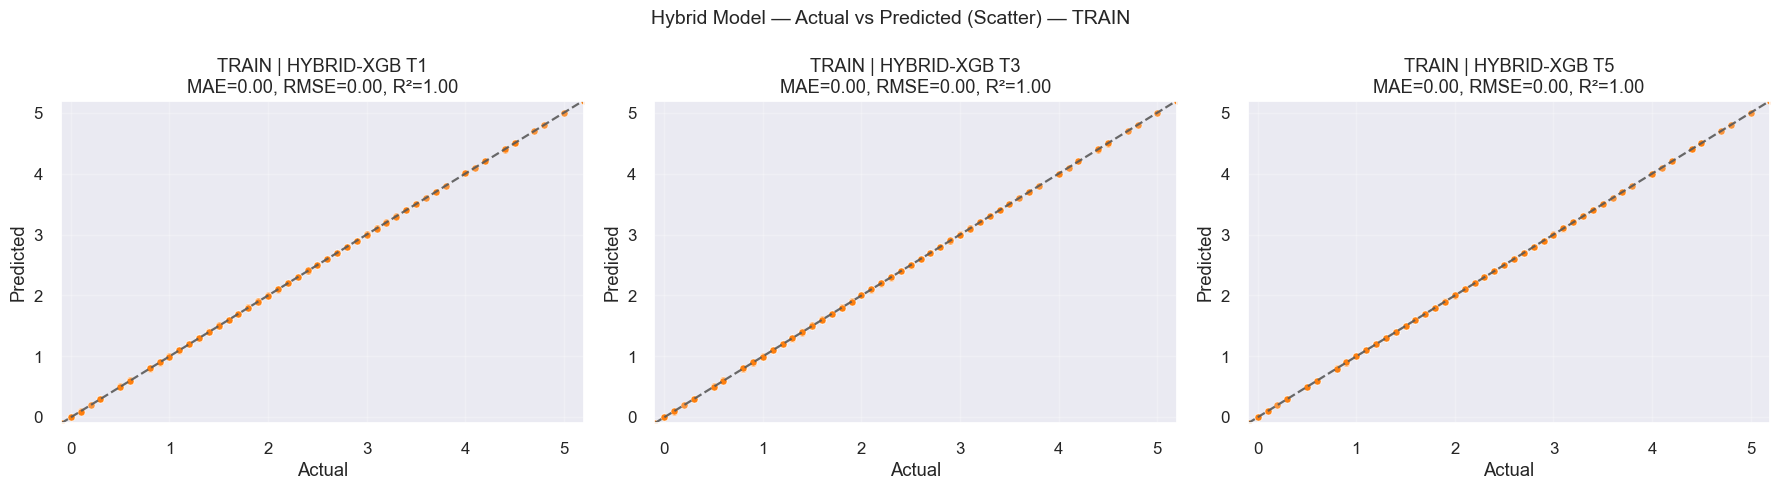

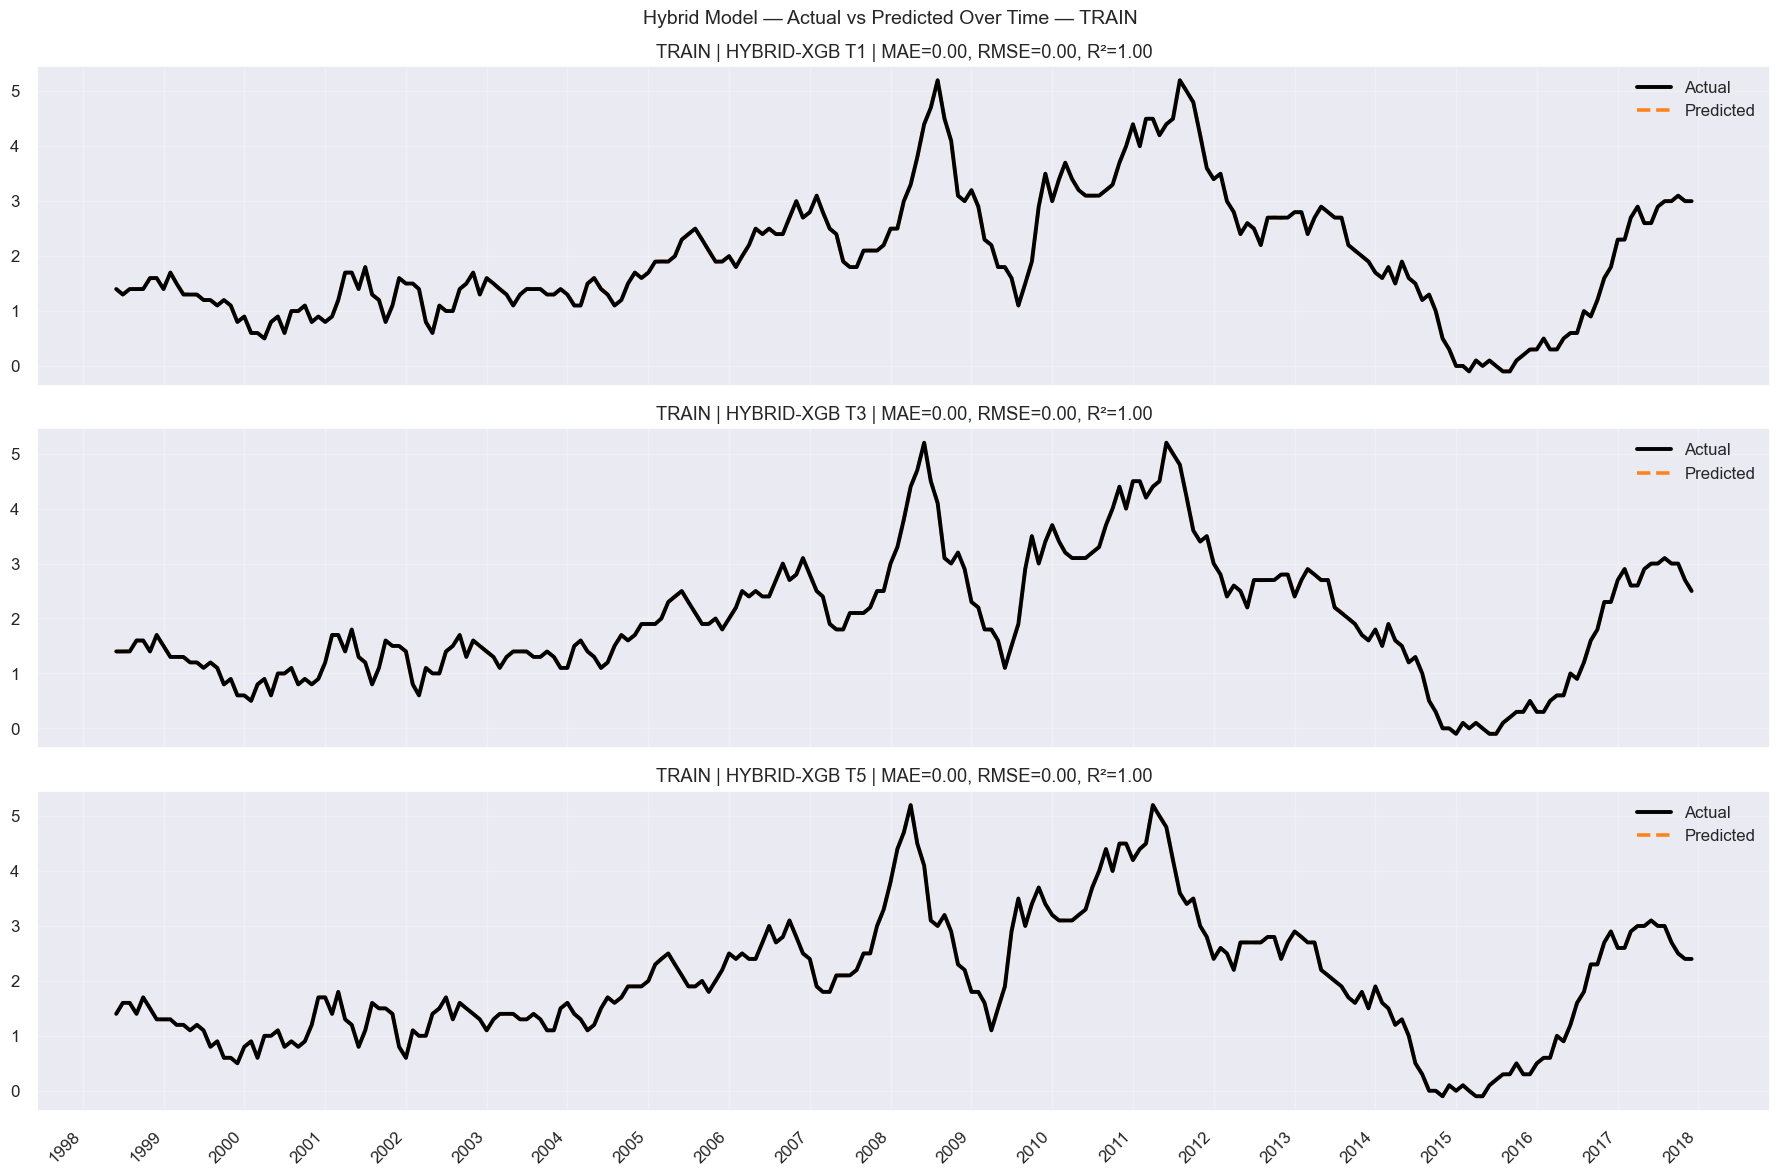

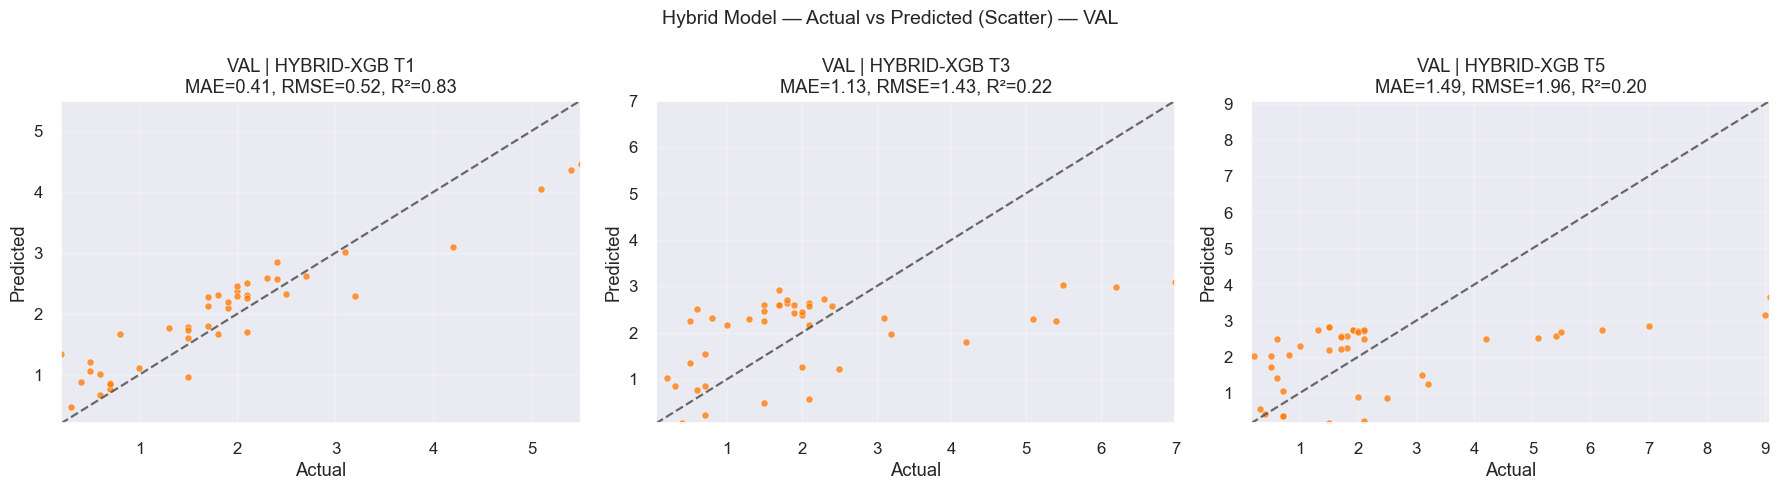

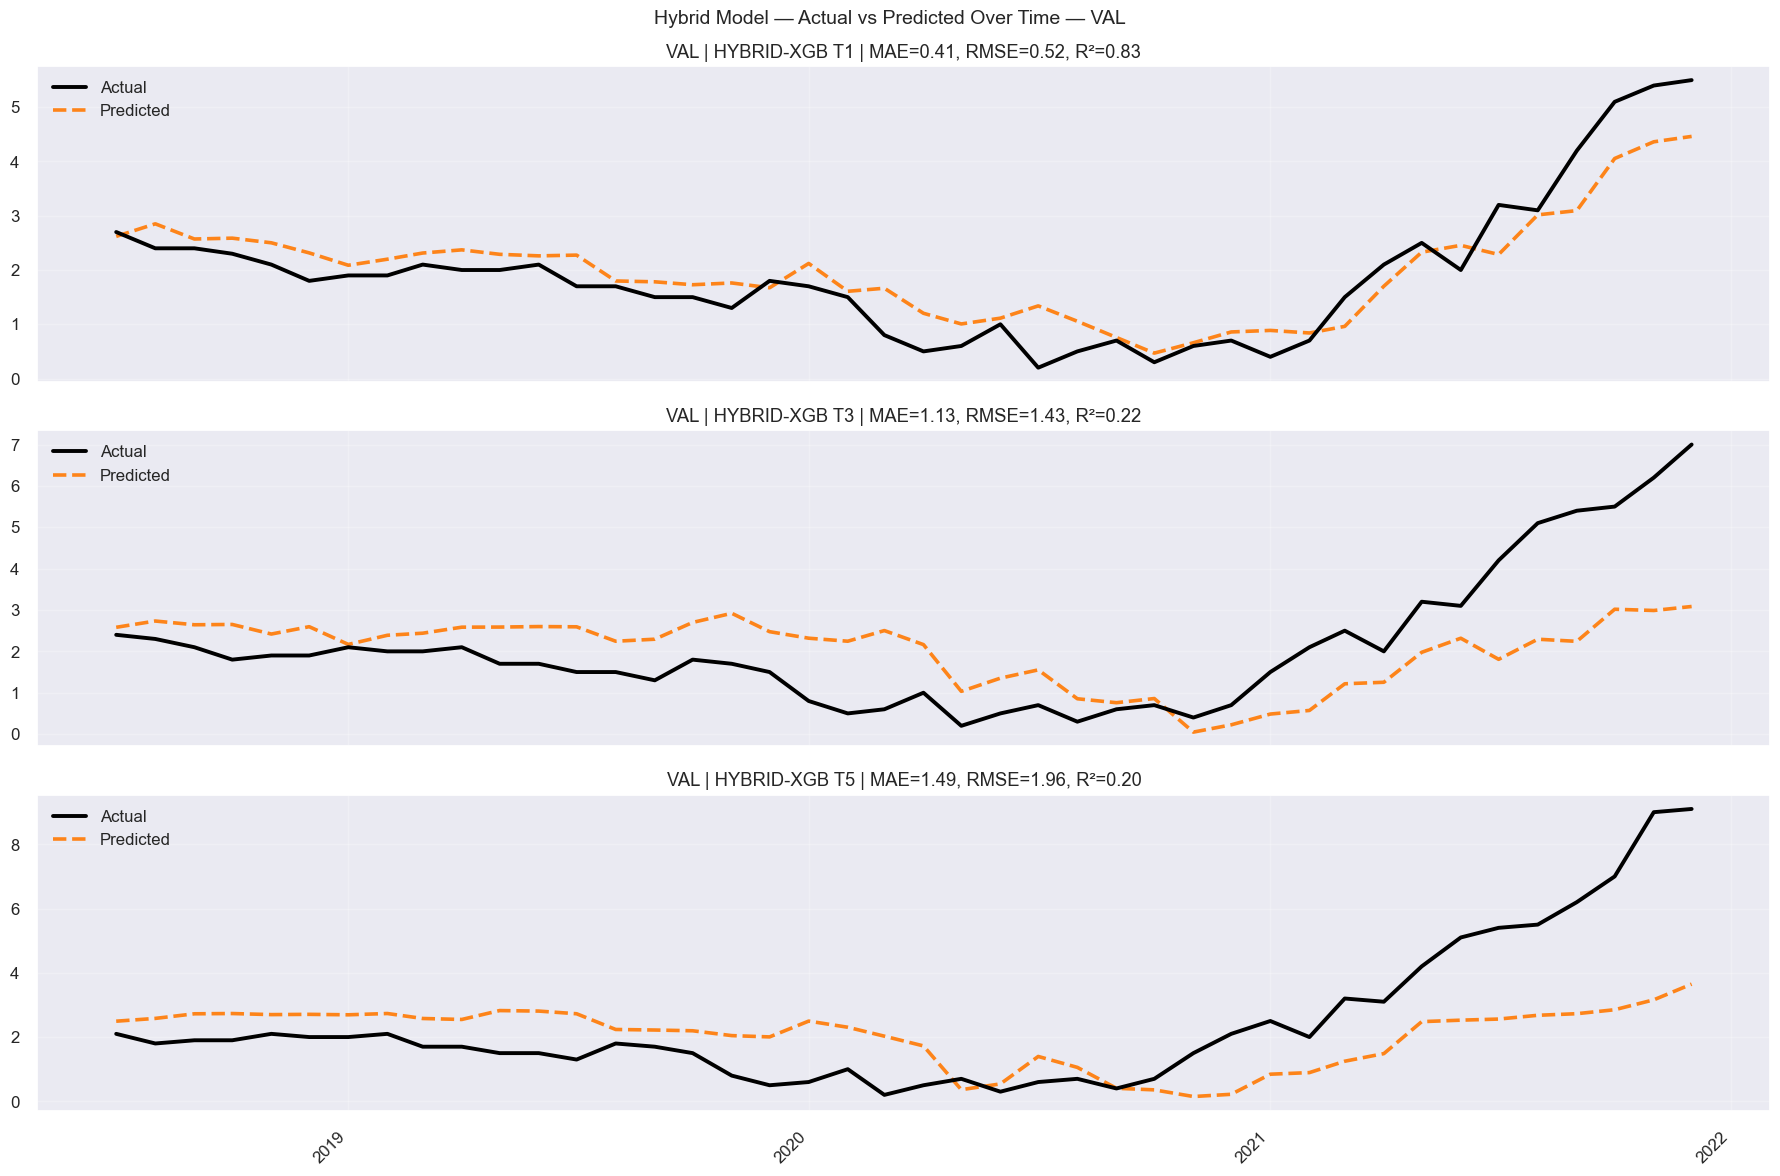

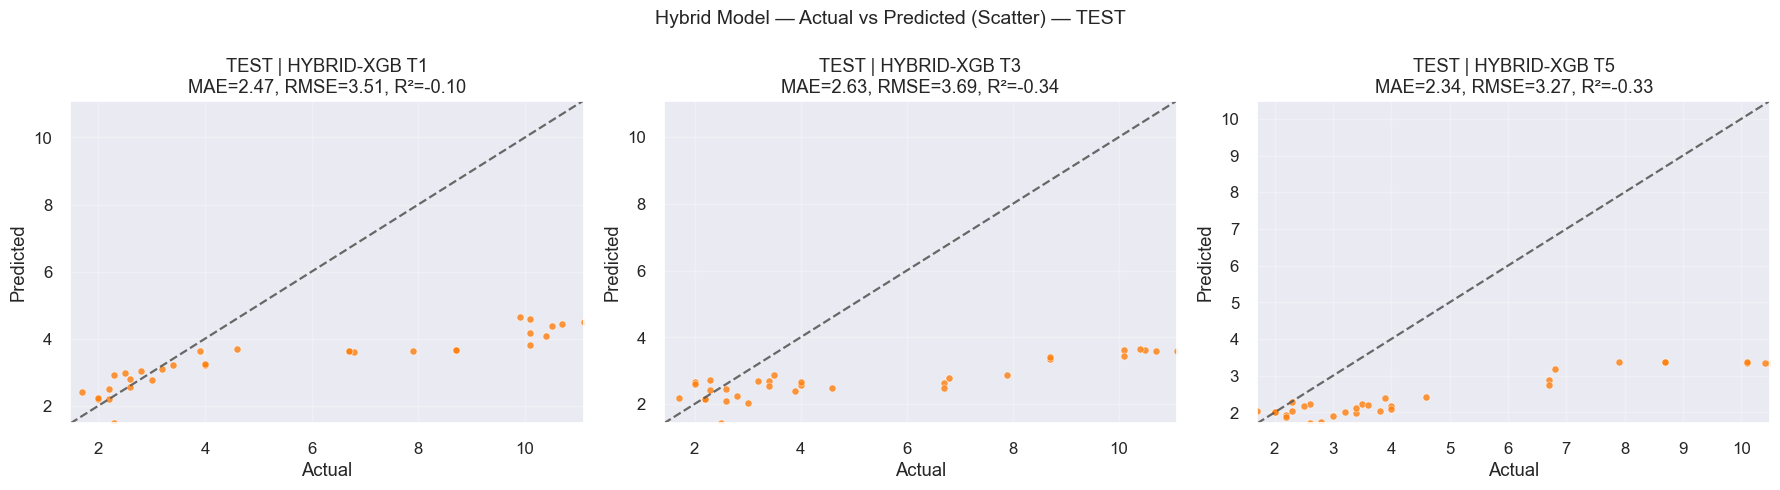

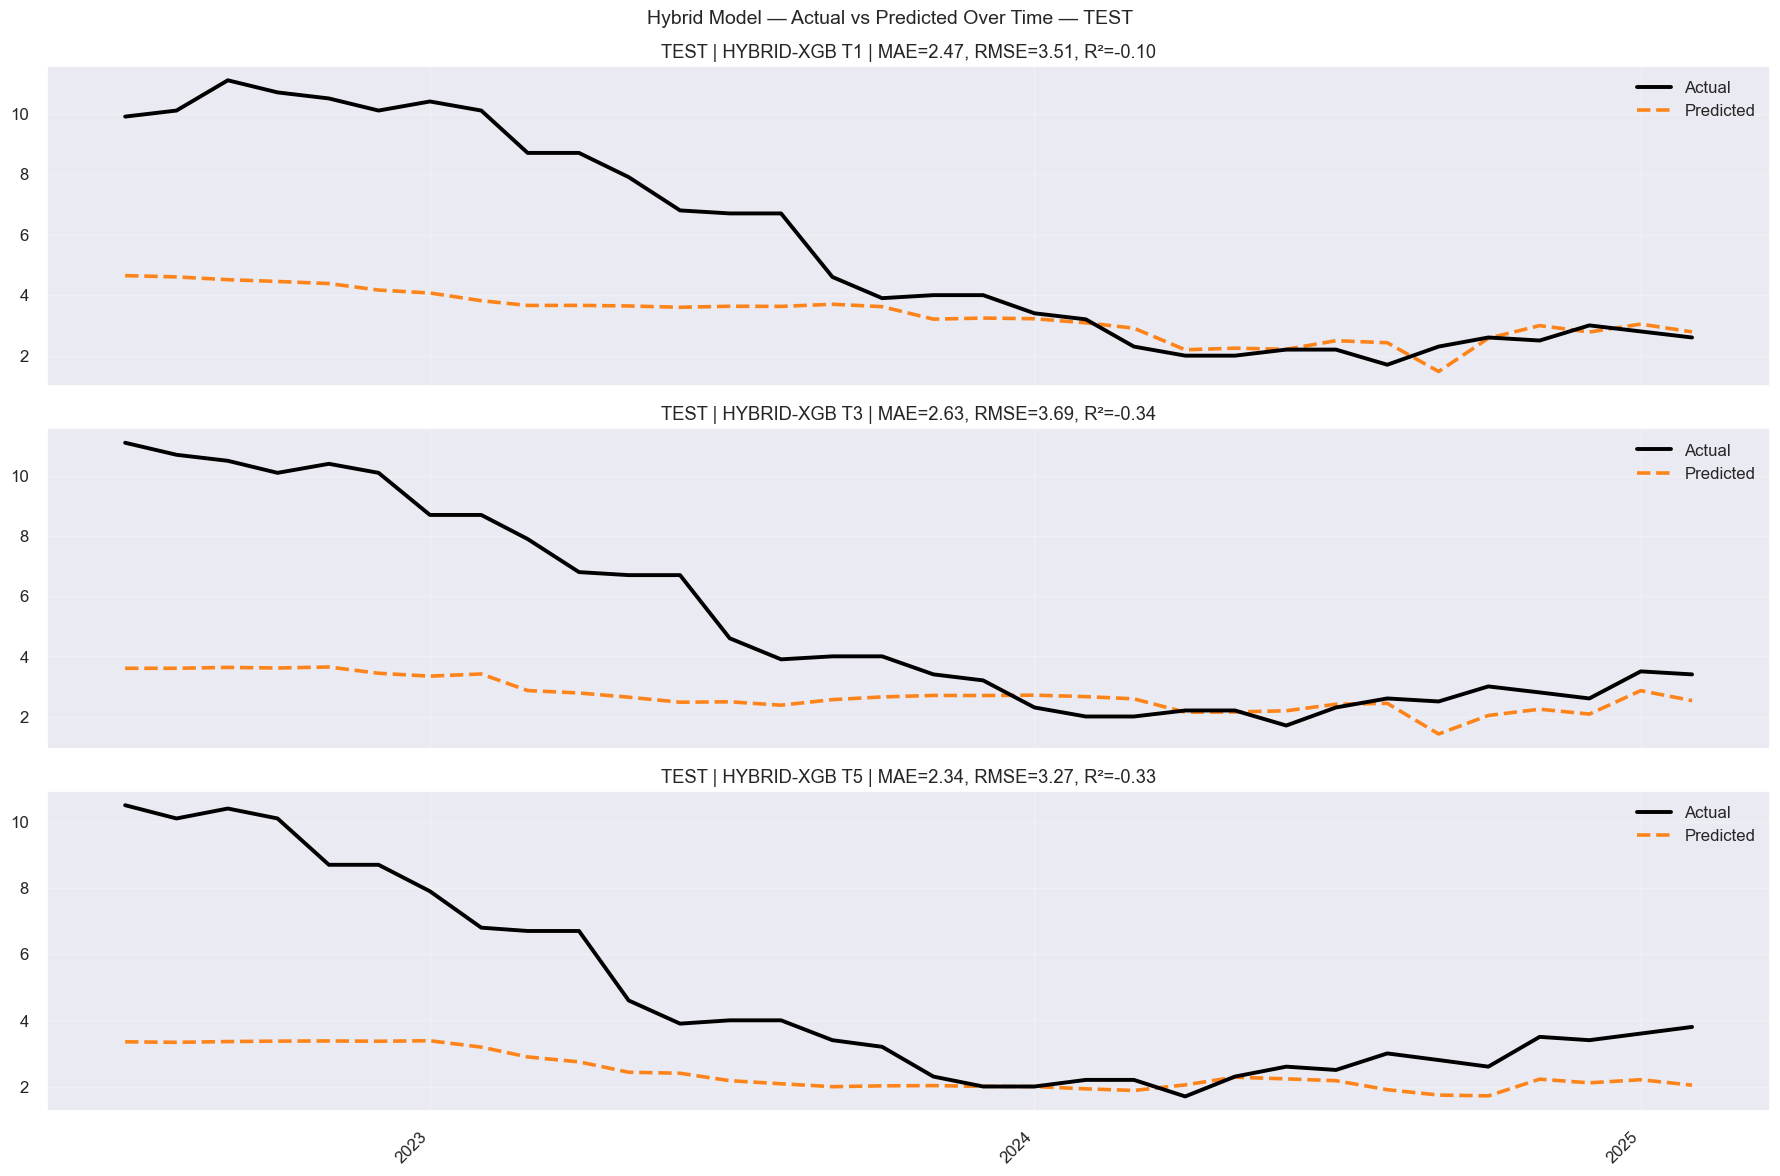

In [17]:
# ==========================================================
# RUN PLOTS FOR ALL SPLITS
# ==========================================================
plot_hybrid_scatter_and_lines_for_split("train")
plot_hybrid_scatter_and_lines_for_split("val")
plot_hybrid_scatter_and_lines_for_split("test")


In [18]:
# ==========================================================
# COMPARISON: LSTM (Stage 1) vs HYBRID-XGB (Stage 2)
# - Prints MAE / RMSE / R² for both stages, per split & horizon
# - Plots Actual vs LSTM vs HYBRID-XGB lines for each horizon
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# High-contrast style for clear separation
_CMP_ACTUAL = {"color": "black", "linewidth": 2.8, "alpha": 1.0, "zorder": 3}
_CMP_LSTM   = {"color": "tab:blue", "linewidth": 2.2, "alpha": 0.9, "linestyle": "--", "zorder": 2}
_CMP_HYBRID = {"color": "tab:orange", "linewidth": 2.6, "alpha": 0.95, "linestyle": "-", "zorder": 2}

# Map split names to the corresponding prediction and target frames
_comparison_splits = {
    "train": (lstm_preds_train, xgb_preds_train, y_train),
    "val":   (lstm_preds_val,   xgb_preds_val,   y_val),
    "test":  (lstm_preds_test,  xgb_preds_test,  y_test),
}

def build_comparison_df(split_name):
    """
    Build a DataFrame with date, actual CPI, LSTM predictions, and HYBRID-XGB
    predictions for all horizons, for the requested split.
    Rows with missing predictions for either stage are removed.
    """
    lstm_df, xgb_df, y_df = _comparison_splits[split_name]

    df = pd.DataFrame({
        "date": pd.to_datetime(lstm_df["date"])
    })

    horizons_short = ["t1", "t3", "t5"]
    targets = ["cpi_t1", "cpi_t3", "cpi_t5"]
    
    for h_short, target in zip(horizons_short, targets):
        df[f"actual_{h_short}"] = y_df[target].values
        df[f"lstm_{h_short}"]   = lstm_df[f"lstm_pred_{h_short}"]
        df[f"xgb_{h_short}"]    = xgb_df[f"hybrid_pred_{h_short}"]

    # Drop any row where LSTM or HYBRID prediction is NaN for any horizon
    drop_cols = [
        "lstm_t1", "xgb_t1",
        "lstm_t3", "xgb_t3",
        "lstm_t5", "xgb_t5",
    ]
    mask = ~df[drop_cols].isna().any(axis=1)
    return df.loc[mask].reset_index(drop=True)


def compute_stage_metrics():
    """
    Compute MAE / RMSE / R² for LSTM and HYBRID-XGB for
    each split (train/val/test) and horizon (t1/t3/t5).
    Returns a tidy DataFrame.
    """
    rows = []
    horizons_short = ["t1", "t3", "t5"]
    for split_name in ["train", "val", "test"]:
        df = build_comparison_df(split_name)
        for h_short in horizons_short:
            y_true = df[f"actual_{h_short}"]
            for stage, col in [("LSTM", f"lstm_{h_short}"), ("HYBRID_XGB", f"xgb_{h_short}")]:
                y_pred = df[col]
                mae  = mean_absolute_error(y_true, y_pred)
                rmse = np.sqrt(mean_squared_error(y_true, y_pred))
                r2   = r2_score(y_true, y_pred)
                rows.append({
                    "split": split_name.upper(),
                    "horizon": h_short.upper(),
                    "stage": stage,
                    "MAE": mae,
                    "RMSE": rmse,
                    "R2": r2,
                })
    return pd.DataFrame(rows)


def print_stage_metrics():
    """Pretty-print comparison metrics for each split."""
    metrics_df = compute_stage_metrics()
    for split in ["TRAIN", "VAL", "TEST"]:
        print("\n" + "="*60)
        print(f"METRICS COMPARISON — {split}")
        print("="*60)
        display(metrics_df[metrics_df["split"] == split])


def plot_stage_comparison_lines_for_split(split_name):
    """
    For a given split ("train", "val", "test"), plot time-series lines
    comparing Actual vs LSTM vs HYBRID-XGB for each horizon.
    """
    df = build_comparison_df(split_name)
    horizons_short = ["t1", "t3", "t5"]
    targets = ["cpi_t1", "cpi_t3", "cpi_t5"]
    dates = df["date"]

    fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
    for ax, h_short, target in zip(axes, horizons_short, targets):
        y_true   = df[f"actual_{h_short}"]
        y_lstm   = df[f"lstm_{h_short}"]
        y_hybrid = df[f"xgb_{h_short}"]

        # Metrics for titles
        m_lstm = {
            "MAE": mean_absolute_error(y_true, y_lstm),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_lstm)),
            "R2": r2_score(y_true, y_lstm),
        }
        m_xgb = {
            "MAE": mean_absolute_error(y_true, y_hybrid),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_hybrid)),
            "R2": r2_score(y_true, y_hybrid),
        }

        ax.plot(dates, y_true,   label="Actual",               **_CMP_ACTUAL)
        ax.plot(dates, y_lstm,   label="LSTM (Stage 1)",       **_CMP_LSTM)
        ax.plot(dates, y_hybrid, label="Hybrid-XGB (Stage 2)", **_CMP_HYBRID)

        ax.set_title(
            f"{split_name.upper()} | {target} | "
            f"LSTM RMSE={m_lstm['RMSE']:.2f}, R²={m_lstm['R2']:.2f} | "
            f"HYBRID RMSE={m_xgb['RMSE']:.2f}, R²={m_xgb['R2']:.2f}"
        )
        ax.grid(True, alpha=0.25)
        ax.legend()

    # Yearly ticks on x-axis for readability
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha="right")
    plt.suptitle(
        f"LSTM vs Hybrid-XGB — Actual vs Predicted ({split_name.upper()})",
        fontsize=14,
    )
    plt.tight_layout()
    plt.show()



METRICS COMPARISON — TRAIN


,split,horizon,stage,MAE,RMSE,R2
0,TRAIN,T1,LSTM,0.482981,0.620624,0.699521
1,TRAIN,T1,HYBRID_XGB,0.004121,0.004800,0.999982
2,TRAIN,T3,LSTM,0.472136,0.593956,0.724744
3,TRAIN,T3,HYBRID_XGB,0.004034,0.004963,0.999981
4,TRAIN,T5,LSTM,0.573144,0.693483,0.624281
5,TRAIN,T5,HYBRID_XGB,0.000778,0.000938,0.999999



METRICS COMPARISON — VAL


,split,horizon,stage,MAE,RMSE,R2
6,VAL,T1,LSTM,0.735344,1.058869,0.309513
7,VAL,T1,HYBRID_XGB,0.413413,0.520706,0.833023
8,VAL,T3,LSTM,1.167295,1.641291,-0.026971
9,VAL,T3,HYBRID_XGB,1.129375,1.434274,0.215756
10,VAL,T5,LSTM,1.325447,2.011238,0.160766
11,VAL,T5,HYBRID_XGB,1.486140,1.959708,0.203219



METRICS COMPARISON — TEST


,split,horizon,stage,MAE,RMSE,R2
12,TEST,T1,LSTM,2.176864,2.957047,0.220063
13,TEST,T1,HYBRID_XGB,2.469676,3.512433,-0.100422
14,TEST,T3,LSTM,2.733244,3.559723,-0.250289
15,TEST,T3,HYBRID_XGB,2.629302,3.686317,-0.340797
16,TEST,T5,LSTM,2.340992,3.004061,-0.121570
17,TEST,T5,HYBRID_XGB,2.340931,3.266387,-0.326001


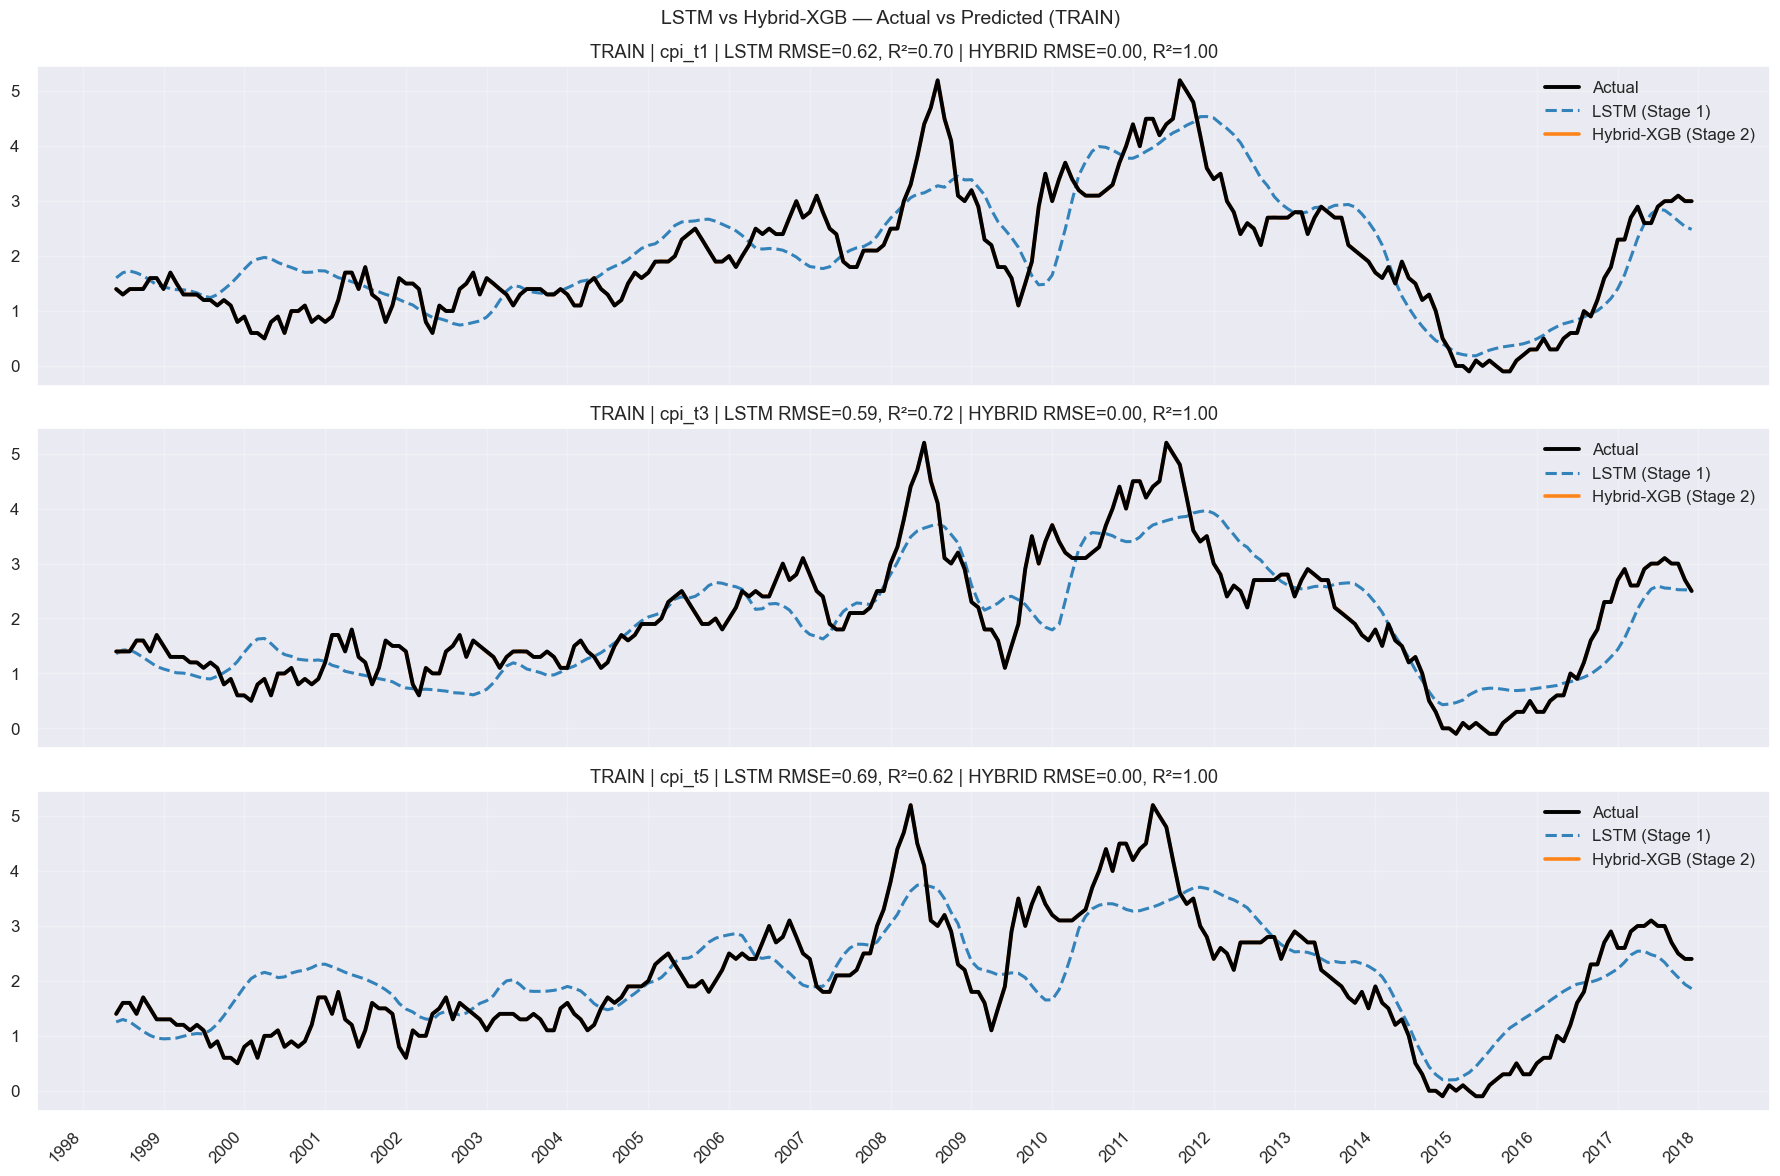

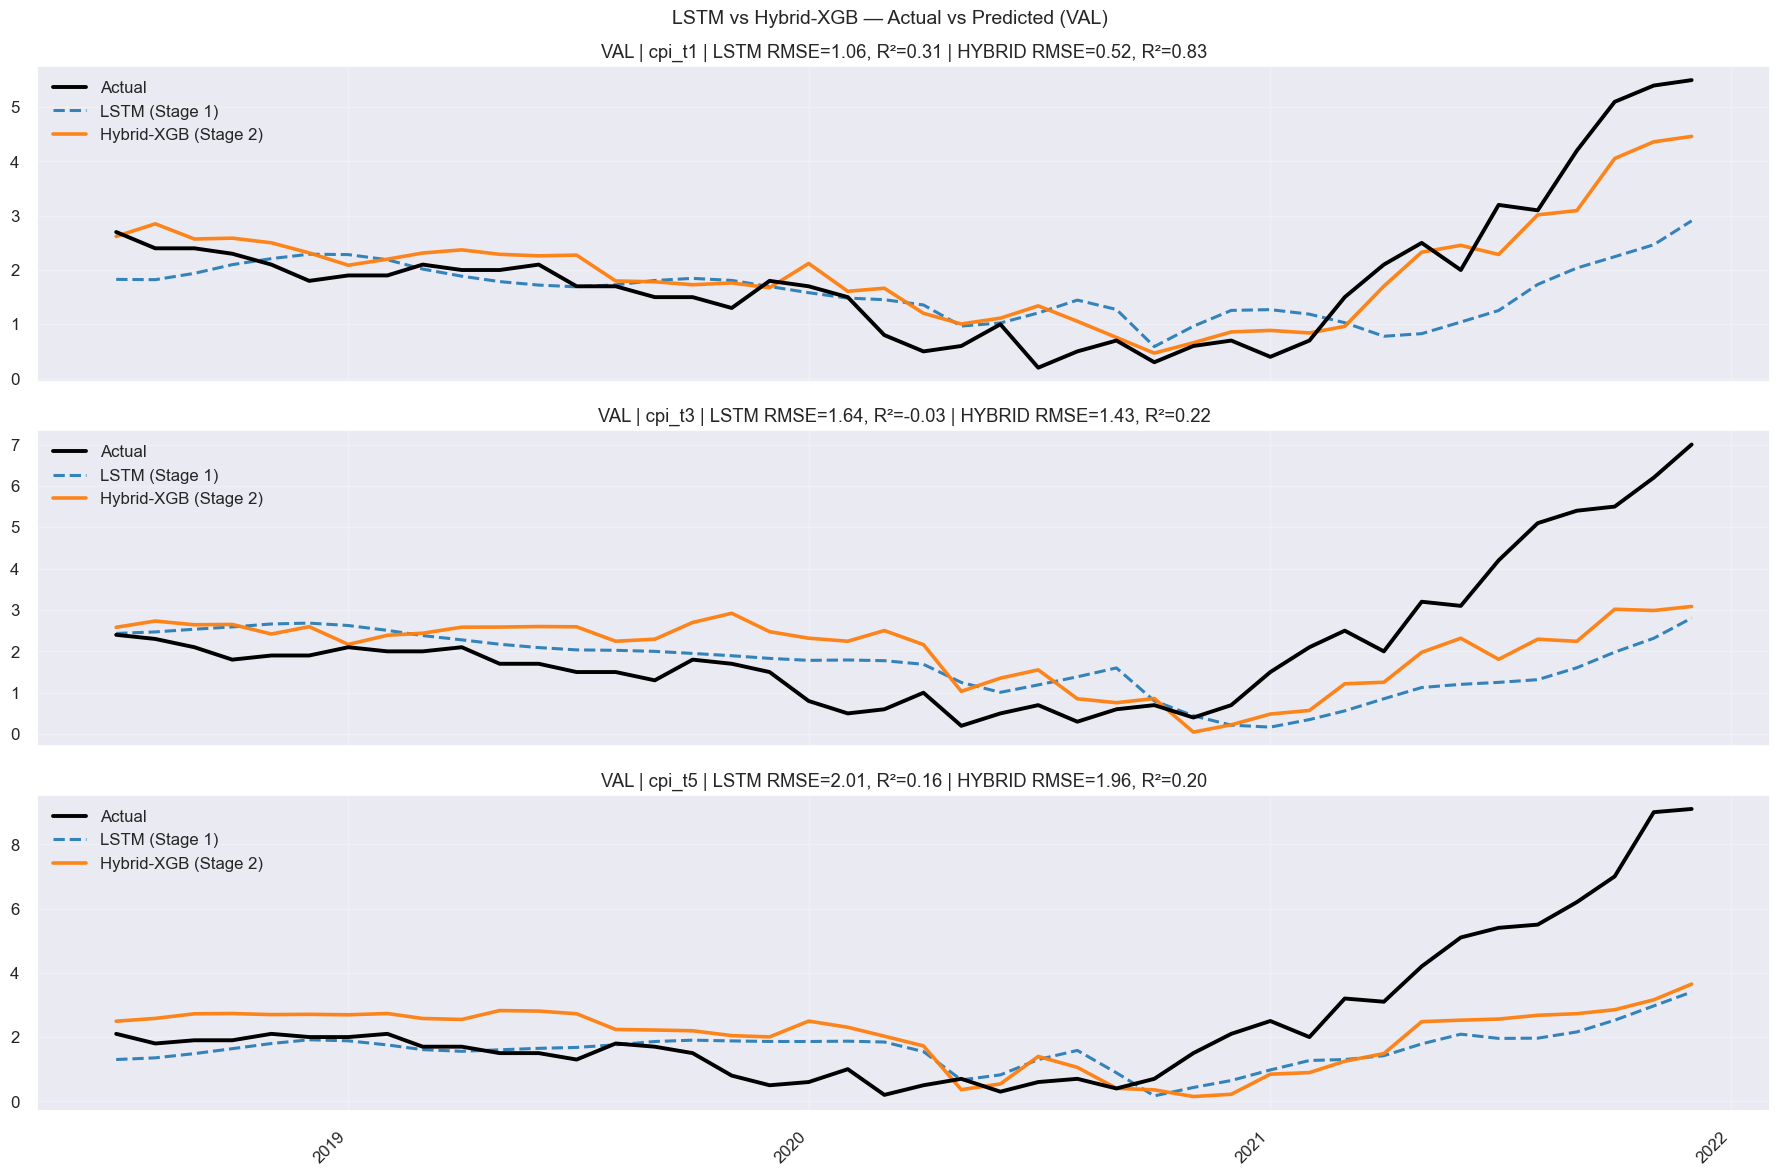

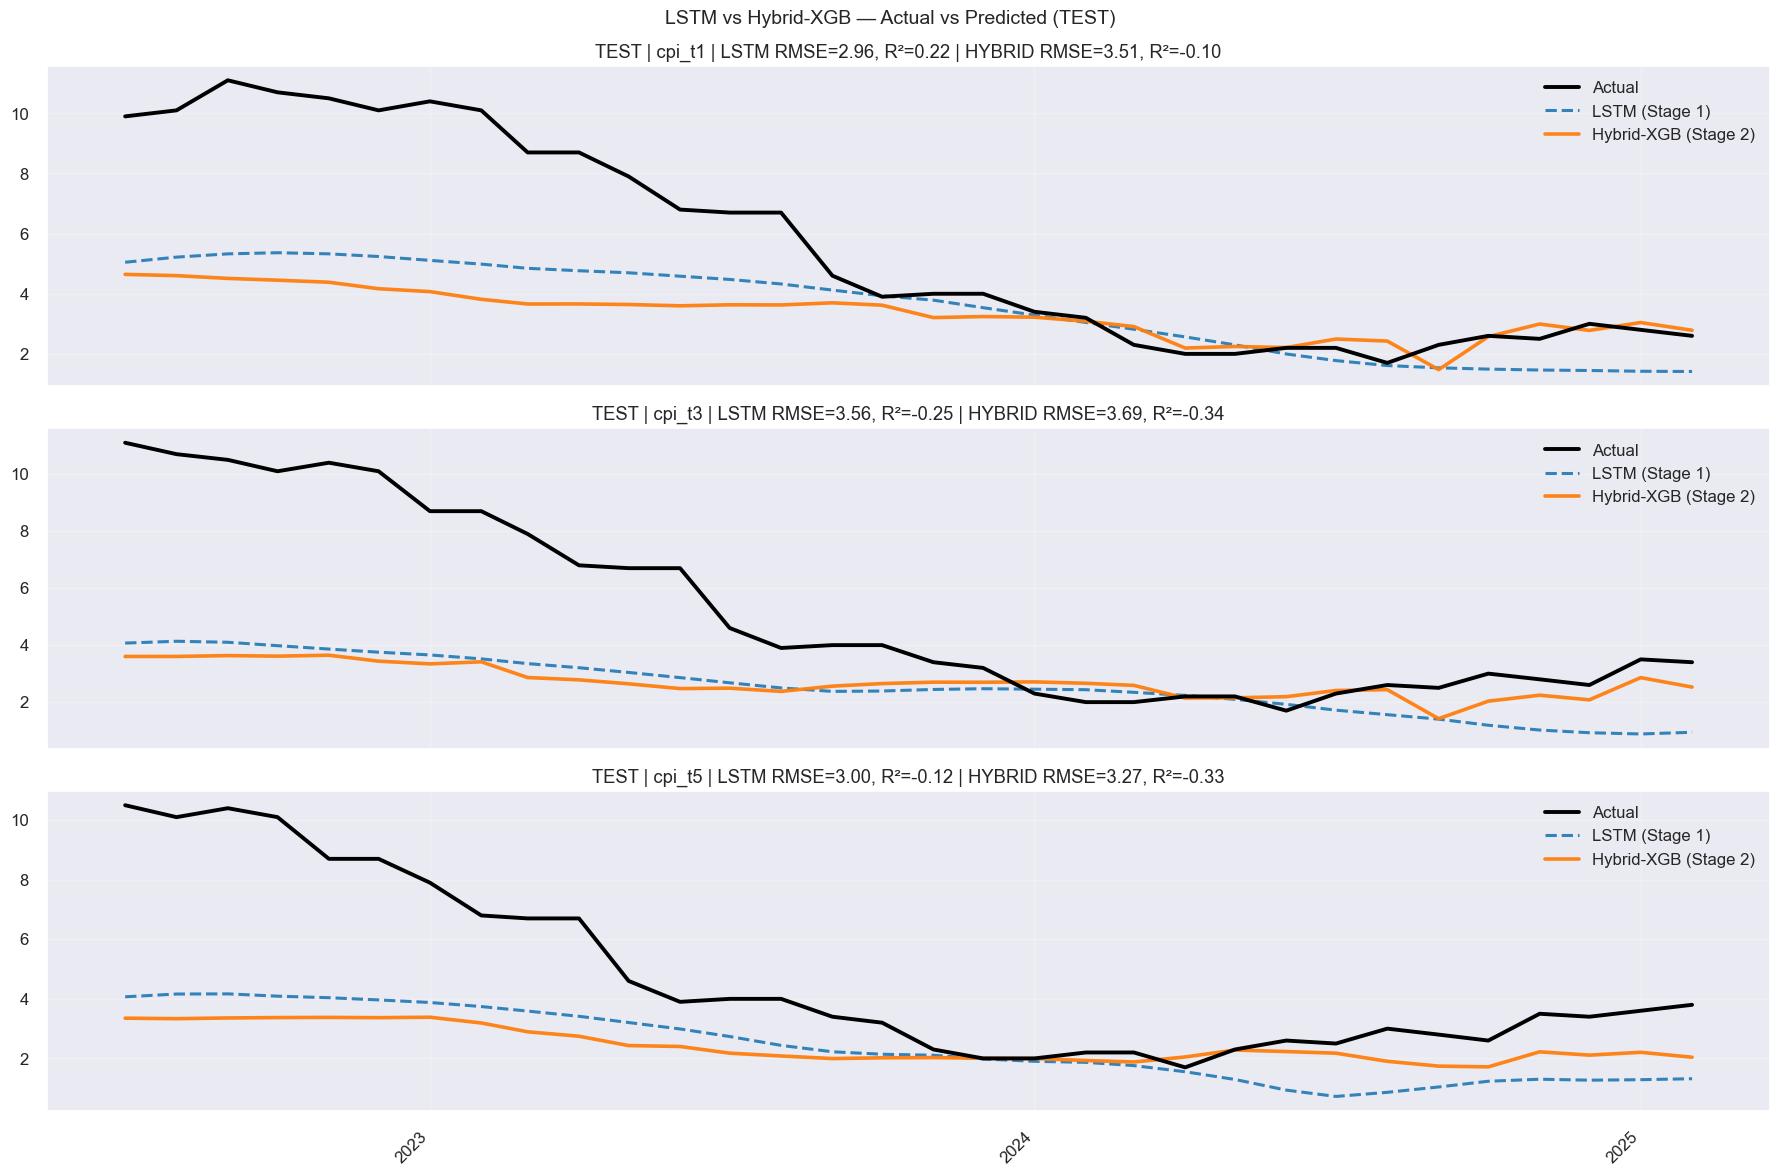

In [19]:
# ==========================================================
# RUN COMPARATIVE METRICS + LINE PLOTS (LSTM vs HYBRID-XGB)
# ==========================================================

print_stage_metrics()

plot_stage_comparison_lines_for_split("train")
plot_stage_comparison_lines_for_split("val")
plot_stage_comparison_lines_for_split("test")


## SHAP Analysis for the Hybrid XGBoost Model (Stage 2)

This section applies **SHapley Additive exPlanations (SHAP)** to interpret the second-stage XGBoost
models used in the hybrid inflation forecasting framework. SHAP is a model-agnostic explainability
method grounded in cooperative game theory that decomposes each prediction into additive feature
contributions relative to a baseline expectation.

SHAP is particularly well suited for the present study because the final forecasting layer is based
on **XGBoost**, a tree-based ensemble model for which exact and computationally efficient SHAP values
can be computed using the TreeSHAP algorithm. This ensures stable, consistent, and theoretically
sound feature attributions. In contrast, applying explainability directly to the LSTM component is
less reliable due to the opaque and highly nonlinear nature of recurrent neural networks.

The analysis is conducted **on the test set only**, focusing on out-of-sample predictions, which is
most relevant for evaluating real-world forecasting behaviour. Separate SHAP analyses are performed
for the one-, three-, and five-month-ahead horizons (`cpi_t1`, `cpi_t3`, `cpi_t5`). For each horizon,
SHAP values are computed using the final trained XGBoost model and the corresponding stacked feature
matrix consisting of macroeconomic variables and the LSTM-derived temporal signal.

Global feature importance is assessed using SHAP summary and bar plots, highlighting the relative
contribution of each predictor to inflation forecasts. Particular attention is given to the ranking
of the LSTM prediction feature, which indicates the extent to which learned temporal dynamics
contribute to the final hybrid forecast.


In [20]:
# =========================
# (1) SHAP setup + TEST matrices
# =========================
import shap

# Store test design matrices + SHAP values
X_test_stack = {}
y_test_stack = {}
dates_test_stack = {}
shap_values_test = {}
shap_explainers = {}

horizons = ["cpi_t1", "cpi_t3", "cpi_t5"]

for h in horizons:
    # Use same stacked features as in Stage 2 XGBoost (Stage 2 training)
    lb = best_params[h]["lookback"]
    h_short = h[-2:]
    pred_col = f"lstm_pred_{h_short}"
    
    # Build stacked X and y for TEST split using existing helper
    Xte_s, yte_s = build_stacked_split(X_test, y_test, lstm_preds_test, h, lb)
    X_test_stack[h] = Xte_s
    y_test_stack[h] = yte_s
    
    # Derive corresponding dates (apply same non-NaN mask as stacking)
    mask = ~np.isnan(lstm_preds_test[pred_col].to_numpy())
    dates_test_stack[h] = dates_test[mask].reset_index(drop=True)
    
    # TreeSHAP explainer for the final XGBoost model (Stage 2)
    explainer = shap.TreeExplainer(xgb_final_models[h])
    shap_explainers[h] = explainer
    
    # SHAP values on TEST stacked features
    shap_values_test[h] = explainer.shap_values(Xte_s)

print("SHAP ready. TEST rows per horizon:")
for h in horizons:
    print(h, "->", X_test_stack[h].shape)


C:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP ready. TEST rows per horizon:
cpi_t1 -> (32, 15)
cpi_t3 -> (32, 15)
cpi_t5 -> (32, 15)



SHAP GLOBAL IMPORTANCE (TEST): cpi_t1


C:\Users\reset\AppData\Local\Temp\ipykernel_23316\2447509938.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xte, plot_type="bar", show=True)


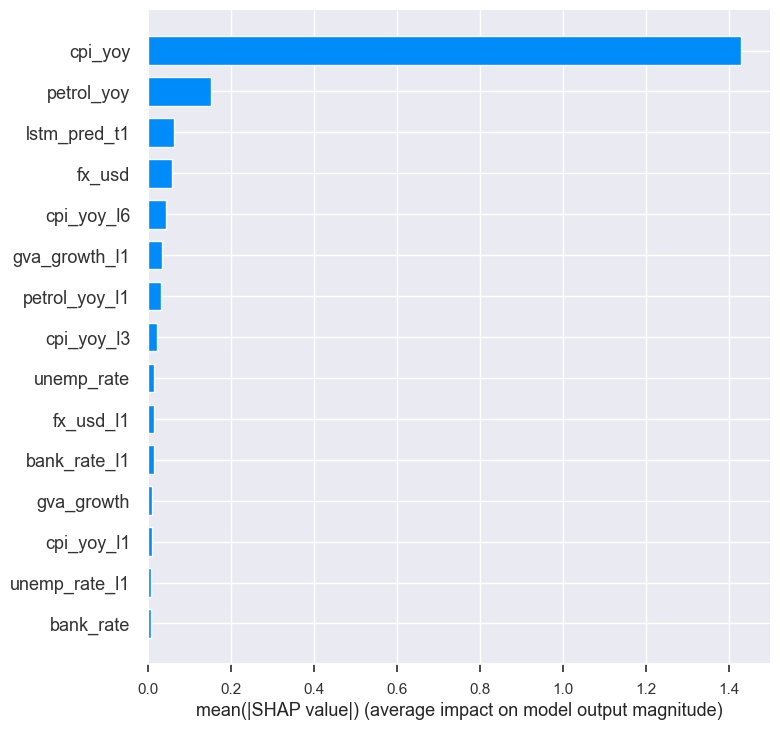

C:\Users\reset\AppData\Local\Temp\ipykernel_23316\2447509938.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xte, show=True)


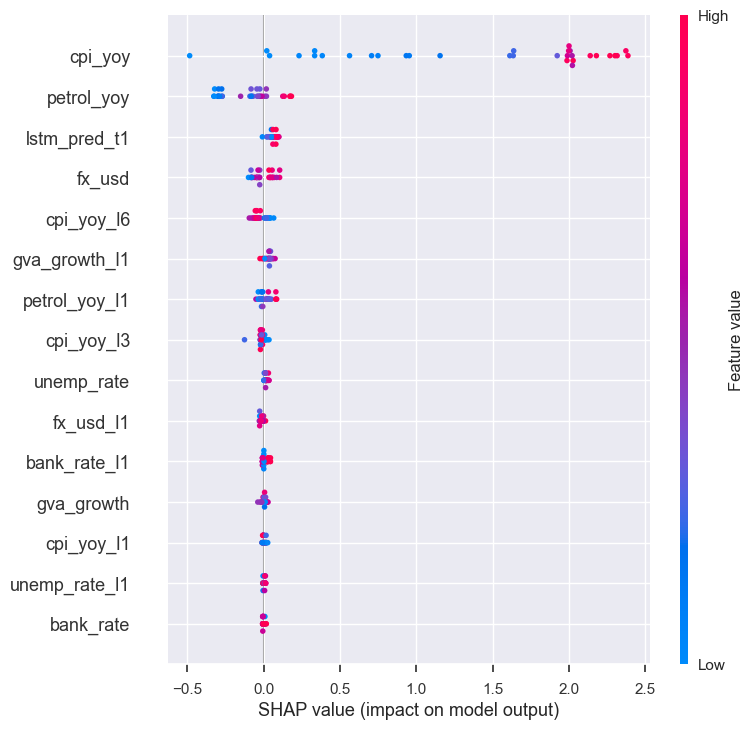


SHAP GLOBAL IMPORTANCE (TEST): cpi_t3


C:\Users\reset\AppData\Local\Temp\ipykernel_23316\2447509938.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xte, plot_type="bar", show=True)


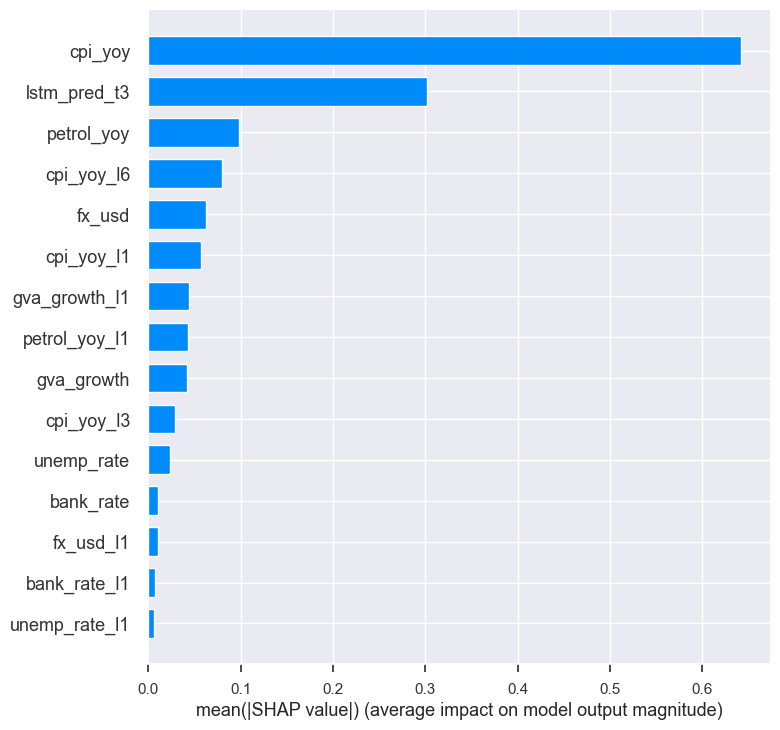

C:\Users\reset\AppData\Local\Temp\ipykernel_23316\2447509938.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xte, show=True)


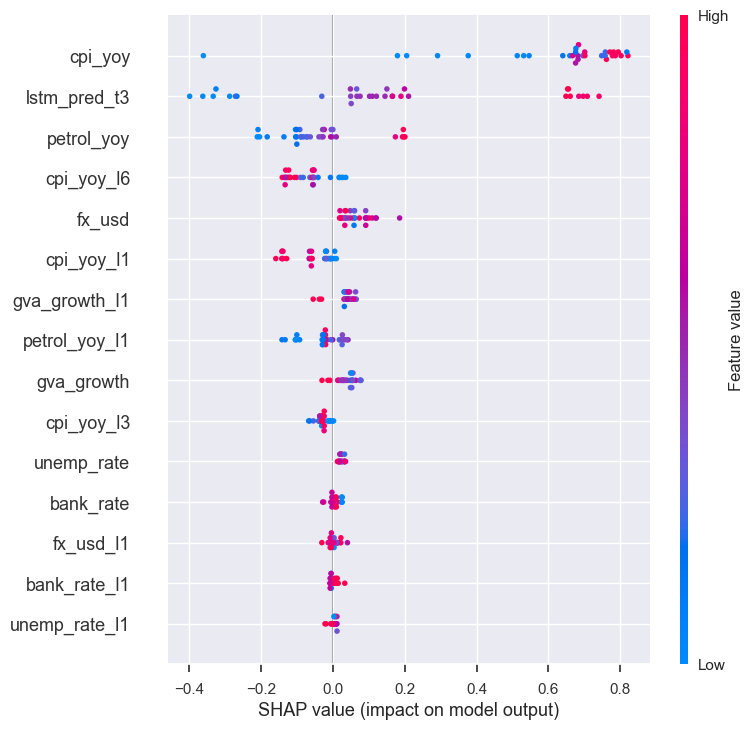


SHAP GLOBAL IMPORTANCE (TEST): cpi_t5


C:\Users\reset\AppData\Local\Temp\ipykernel_23316\2447509938.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xte, plot_type="bar", show=True)


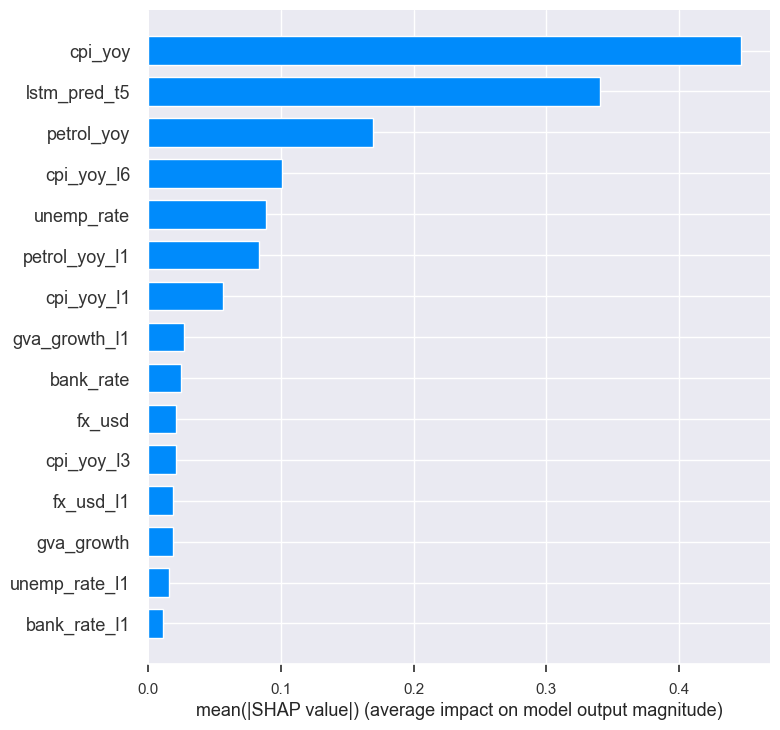

C:\Users\reset\AppData\Local\Temp\ipykernel_23316\2447509938.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, Xte, show=True)


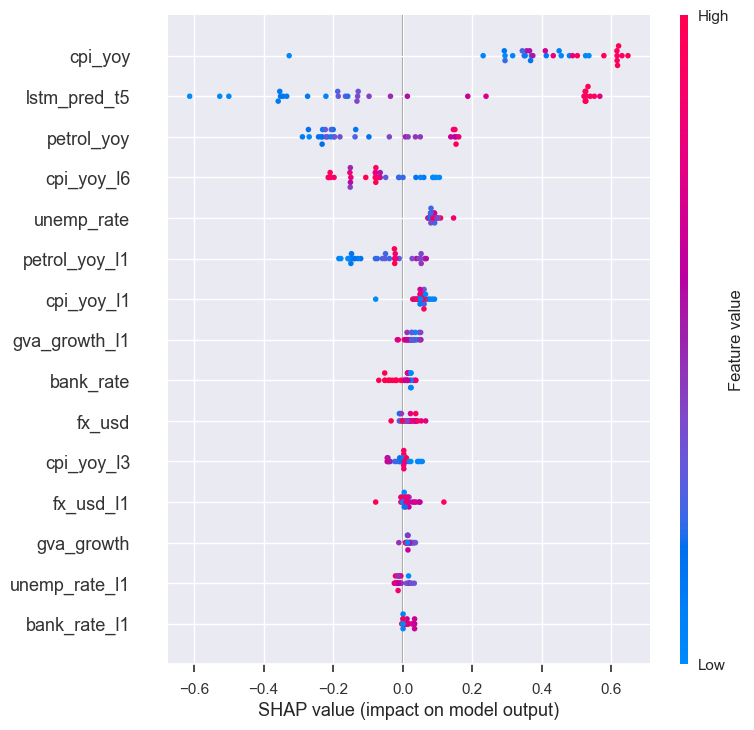

In [21]:
# =========================
# (2) Global SHAP plots (TEST-only)
# - Bar plot (thesis-friendly)
# - Beeswarm (directionality)
# =========================
for h in ["cpi_t1", "cpi_t3", "cpi_t5"]:
    Xte = X_test_stack[h]
    sv  = shap_values_test[h]

    print("\n" + "="*60)
    print("SHAP GLOBAL IMPORTANCE (TEST):", h)
    print("="*60)

    # Thesis-friendly global ranking
    shap.summary_plot(sv, Xte, plot_type="bar", show=True)

    # Diagnostic: importance + direction
    shap.summary_plot(sv, Xte, show=True)


Horizon: cpi_t1
Test date: 2023-05-01
Actual: 7.9
Predicted: 3.6419911


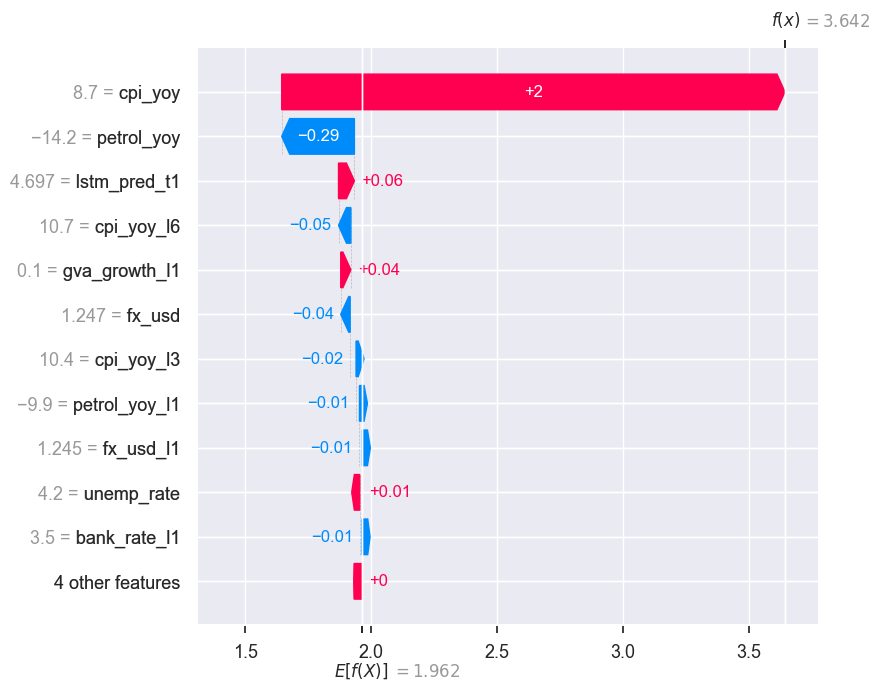

In [22]:
# =========================
# (3) Local explanation (Waterfall) — choose 1 test observation
# Edit:
#   horizon_to_explain = "cpi_t1" or "cpi_t3" or "cpi_t5"
#   i = index within the *cleaned* TEST set (after NaNs removed)
# =========================
horizon_to_explain = "cpi_t1"
i = 10  # change this index as needed

Xte = X_test_stack[horizon_to_explain]
explainer = shap_explainers[horizon_to_explain]

# Build Explanation object for waterfall plotting
sv_exp = explainer(Xte)

print("Horizon:", horizon_to_explain)
print("Test date:", dates_test_stack[horizon_to_explain].iloc[i])
print("Actual:", y_test_stack[horizon_to_explain][i])
print("Predicted:", xgb_final_models[horizon_to_explain].predict(Xte)[i])

shap.plots.waterfall(sv_exp[i], max_display=12)


## LIME (Local Interpretable Model-agnostic Explanations) for the Hybrid XGBoost Model

This section applies **LIME** to provide complementary local explanations for individual predictions
made by the hybrid XGBoost inflation forecasting model. Unlike SHAP, which uses Shapley values from
cooperative game theory, LIME explains individual predictions by fitting a simple linear approximation
in the neighbourhood of a specific test observation.

### Key Advantages of LIME

1. **Model-agnostic**: Works with any black-box model without requiring internal structure.
2. **Local focus**: Explains *why* a specific prediction was made, not global feature importance.
3. **Interpretable surrogate**: Replaces the complex XGBoost model with a simple, human-readable linear model.
4. **Feature interactions**: Reveals which features drove a particular forecast at a given point in time.

### Implementation Strategy

- **Analysis scope**: Test set only (consistent with SHAP analysis for out-of-sample evaluation).
- **Horizons**: Separate LIME explanations for `cpi_t1`, `cpi_t3`, and `cpi_t5`.
- **Individual instances**: Select any test observation to generate a local explanation showing:
  - Which macroeconomic features and LSTM prediction contributed to that specific forecast.
  - The magnitude and direction (push up or down) of each feature's local effect.
  - A comparison between the actual value, XGBoost prediction, and LIME approximation.

### Output Format

For each selected observation, a bar chart ranks features by their contribution to the prediction,
with positive/negative colours indicating direction of influence relative to the model baseline.

LIME explainers initialized for all horizons (TEST set)

LIME LOCAL EXPLANATION — cpi_t1
Test date    : 2023-05-01
Actual CPI   : 7.9000
Predicted CPI: 3.6420
Error        : 4.2580

------------------------------------------------------------
Top contributing features (LIME):
------------------------------------------------------------
  4.30 < cpi_yoy <= 9.95: 0.8256
  petrol_yoy <= -10.97: -0.1877
  cpi_yoy_l6 > 9.95: -0.0907
  bank_rate_l1 <= 3.50: -0.0279
  -10.97 < petrol_yoy_l1 <= -5.00: -0.0254
  1.22 < fx_usd_l1 <= 1.25: -0.0204
  4.15 < unemp_rate <= 4.30: 0.0187
  3.90 < unemp_rate_l1 <= 4.10: -0.0134
  3.86 < lstm_pred_t1 <= 4.88: 0.0104
  gva_growth <= 0.00: 0.0088
  5.65 < cpi_yoy_l1 <= 9.95: -0.0068
  bank_rate <= 3.50: -0.0032
  1.22 < fx_usd <= 1.25: 0.0028
  0.00 < gva_growth_l1 <= 0.20: 0.0025
  cpi_yoy_l3 > 9.95: 0.0014


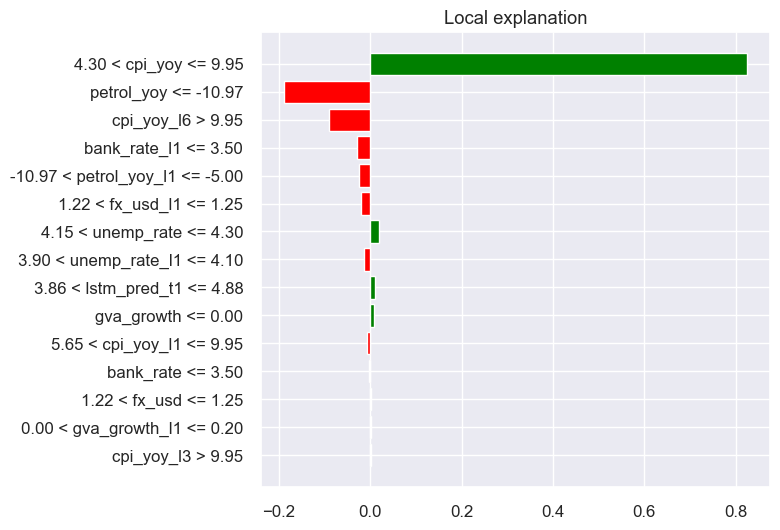

In [23]:
# =========================
# LIME: Local Explanations
# =========================
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np

# Initialize LIME explainers for each horizon (test set)
lime_explainers = {}

horizons = ["cpi_t1", "cpi_t3", "cpi_t5"]

for h in horizons:
    Xte = X_test_stack[h]
    
    # LIME explainer: training data is the TEST set for local neighbourhood sampling
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=Xte.values,
        feature_names=Xte.columns.tolist(),
        mode="regression",
        random_state=SEED,
        verbose=False
    )
    lime_explainers[h] = explainer

print("LIME explainers initialized for all horizons (TEST set)")


# =========================
# Local LIME explanation for a selected test observation
# Edit the following parameters as needed:
#   horizon_to_explain = "cpi_t1", "cpi_t3", or "cpi_t5"
#   test_idx = index within the cleaned TEST set (after LSTM lookback removed)
# =========================

horizon_to_explain = "cpi_t1"
test_idx = 10  # change this as needed

Xte = X_test_stack[horizon_to_explain]
explainer = lime_explainers[horizon_to_explain]
model = xgb_final_models[horizon_to_explain]

# Get prediction for this observation
instance = Xte.iloc[test_idx].values.reshape(1, -1)
prediction = model.predict(instance)[0]
actual = y_test_stack[horizon_to_explain][test_idx]

# Generate LIME explanation
exp = explainer.explain_instance(
    data_row=instance[0],
    predict_fn=model.predict,
    num_features=15  # show top 15 features
)

print("\n" + "="*60)
print(f"LIME LOCAL EXPLANATION — {horizon_to_explain}")
print("="*60)
print(f"Test date    : {dates_test_stack[horizon_to_explain].iloc[test_idx]}")
print(f"Actual CPI   : {actual:.4f}")
print(f"Predicted CPI: {prediction:.4f}")
print(f"Error        : {abs(actual - prediction):.4f}")
print("\n" + "-"*60)
print("Top contributing features (LIME):")
print("-"*60)
for feat, weight in exp.as_list():
    print(f"  {feat}: {weight:.4f}")

# Visualize LIME explanation
fig = exp.as_pyplot_figure()
plt.tight_layout()
plt.show()

# Save Hybrid Model Artifacts for Evaluation

Save all predictions, dates, and model configurations to the results directory.
These artifacts will be used later to compare the hybrid model performance against the baseline ARIMA model.

In [24]:
import os
import json
import numpy as np
import pandas as pd
from pathlib import Path

# Define results directory
RESULTS_DIR = PROJECT_ROOT / "results" / "hybrid"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("="*70)
print("SAVING HYBRID MODEL ARTIFACTS FOR EVALUATION")
print("="*70)


def _safe_dates_to_str(dates_like: pd.Series) -> pd.Series:
    """Convert a date-like Series (possibly strings) to ISO date strings."""
    dt = pd.to_datetime(dates_like, errors="coerce")
    out = dt.dt.strftime("%Y-%m-%d")
    if out.isna().all():
        return dates_like.astype(str)
    return out


# 1. Save test predictions for all horizons
print("\n1. Saving test predictions...")
for horizon in horizons:
    dates_str = _safe_dates_to_str(dates_test_stack[horizon])

    # Create predictions dataframe
    preds_df = pd.DataFrame({
        "dates": dates_str.values,
        "actual": y_test_stack[horizon],
        "predicted": xgb_final_models[horizon].predict(X_test_stack[horizon]),
    })

    # Save as CSV
    csv_path = RESULTS_DIR / f"xgb_{horizon}_predictions.csv"
    preds_df.to_csv(csv_path, index=False)
    print(f"   ✓ {horizon} predictions saved: {csv_path.name}")

    # Save as NPY for efficient comparison
    npy_path_pred = RESULTS_DIR / f"xgb_{horizon}_test_forecast.npy"
    npy_path_actual = RESULTS_DIR / f"xgb_{horizon}_test_actual.npy"
    np.save(npy_path_pred, preds_df["predicted"].to_numpy())
    np.save(npy_path_actual, np.asarray(y_test_stack[horizon]))
    print(f"   ✓ {horizon} NPY files saved (forecast & actual)")

# 2. Save test dates
print("\n2. Saving test dates...")
dates_output = {}
for horizon in horizons:
    dates_output[horizon] = _safe_dates_to_str(dates_test_stack[horizon]).tolist()

dates_json_path = RESULTS_DIR / "test_dates.json"
with open(dates_json_path, "w") as f:
    json.dump(dates_output, f, indent=2)
print(f"   ✓ Test dates saved: {dates_json_path.name}")

# 3. Save model hyperparameters
print("\n3. Saving model configurations...")
model_config = {
    "model_type": "XGBoost Hybrid (Multi-Horizon)",
    "horizons": horizons,
    "best_hyperparameters": {},
}

for horizon in horizons:
    model = xgb_final_models[horizon]
    model_config["best_hyperparameters"][horizon] = {
        "n_estimators": model.n_estimators,
        "max_depth": model.max_depth,
        "learning_rate": model.learning_rate,
        "subsample": model.subsample,
        "colsample_bytree": model.colsample_bytree,
        "min_child_weight": model.min_child_weight,
        "gamma": model.gamma,
        "reg_alpha": model.reg_alpha,
        "reg_lambda": model.reg_lambda,
    }

config_path = RESULTS_DIR / "xgb_model_config.json"
with open(config_path, "w") as f:
    json.dump(model_config, f, indent=2)
print(f"   ✓ Model configuration saved: {config_path.name}")

# 4. Save feature information
print("\n4. Saving feature information...")
feature_names = {
    "features": X_test_stack[horizons[0]].columns.tolist(),
    "n_features": len(X_test_stack[horizons[0]].columns),
}

features_path = RESULTS_DIR / "xgb_feature_names.json"
with open(features_path, "w") as f:
    json.dump(feature_names, f, indent=2)
print(f"   ✓ Feature names saved: {features_path.name}")

# 5. Save training metrics summary
print("\n5. Saving training summary...")
dates_ref = pd.to_datetime(dates_test_stack[horizons[0]], errors="coerce")
dates_ref = dates_ref.dropna()

summary = {
    "n_test_samples": int(len(X_test_stack[horizons[0]])),
    "test_date_range": {
        "start": (dates_ref.min().strftime("%Y-%m-%d") if len(dates_ref) else None),
        "end": (dates_ref.max().strftime("%Y-%m-%d") if len(dates_ref) else None),
    },
    "horizons_trained": horizons,
    "model_type": "XGBoost (Ensemble Multi-Horizon)",
}

summary_path = RESULTS_DIR / "xgb_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)
print(f"   ✓ Summary saved: {summary_path.name}")

print("\n" + "="*70)
print("ARTIFACTS SAVED SUCCESSFULLY")
print("="*70)
print(f"\nSaved to: {RESULTS_DIR}")
print("\nArtifacts ready for model comparison:")
print("  • Test predictions (CSV & NPY format)")
print("  • Test dates (JSON format)")
print("  • Model hyperparameters (JSON format)")
print("  • Feature information (JSON format)")
print("  • Training summary (JSON format)")
print("\nNext step: Use 06_evaluation.ipynb to compare hybrid vs. baseline models")


SAVING HYBRID MODEL ARTIFACTS FOR EVALUATION

1. Saving test predictions...
   ✓ cpi_t1 predictions saved: xgb_cpi_t1_predictions.csv
   ✓ cpi_t1 NPY files saved (forecast & actual)
   ✓ cpi_t3 predictions saved: xgb_cpi_t3_predictions.csv
   ✓ cpi_t3 NPY files saved (forecast & actual)
   ✓ cpi_t5 predictions saved: xgb_cpi_t5_predictions.csv
   ✓ cpi_t5 NPY files saved (forecast & actual)

2. Saving test dates...
   ✓ Test dates saved: test_dates.json

3. Saving model configurations...
   ✓ Model configuration saved: xgb_model_config.json

4. Saving feature information...
   ✓ Feature names saved: xgb_feature_names.json

5. Saving training summary...
   ✓ Summary saved: xgb_summary.json

ARTIFACTS SAVED SUCCESSFULLY

Saved to: C:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI\results\hybrid

Artifacts ready for model comparison:
  • Test predictions (CSV & NPY format)
  • Test dates (JSON format)
  • Model hyperparameters (JSON format)
  • Feature info